In [1]:
# import sys
# import os
# import tkinter as tk
# from tkinter import filedialog, messagebox, ttk
# import cv2
# import numpy as np
# from PIL import Image, ImageTk

# # Global storage for processing results
# CURRENT_RESULT = None


# # ==========================================
# # 1. OPTIMIZED IMAGE PROCESSING ENGINE
# # ==========================================

# def display_detected_fragments(img):
#     """Segment paper fragments using contour detection."""
#     img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#     h, w, c = img.shape
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#     _, thresh = cv2.threshold(gray, 250, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

#     kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
#     thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
#     thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

#     contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#     min_area = (h * w) * 0.009
#     fragments = [c for c in contours if cv2.contourArea(c) > min_area]

#     if not fragments:
#         return [], w

#     temporary_storage = []
#     for idx, contour in enumerate(fragments):
#         mask = np.zeros_like(gray)
#         cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)
#         piece = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

#         x, y, pw, ph = cv2.boundingRect(contour)
#         cropped_piece = piece[y : y + ph, x : x + pw]
#         cropped_bgr = cv2.cvtColor(cropped_piece, cv2.COLOR_RGB2BGR)

#         temporary_storage.append({"img": cropped_bgr, "orig_x": x, "orig_y": y})

#     return temporary_storage, w


# def get_thresh(img):
#     return cv2.threshold(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 15, 255, cv2.THRESH_BINARY)[1]


# def merge_canvases(imgA, imgB, threshA, threshB, dx, dy):
#     hA, wA = imgA.shape[:2]
#     hB, wB = imgB.shape[:2]
#     min_x, max_x = min(0, dx), max(wA, wB + dx)
#     min_y, max_y = min(0, dy), max(hA, hB + dy)
#     canvas = np.zeros((max_y - min_y, max_x - min_x, 3), dtype=np.uint8)
    
#     canvas[-min_y : -min_y + hA, -min_x : -min_x + wA][threshA > 0] = imgA[threshA > 0]
#     canvas[dy - min_y : dy - min_y + hB, dx - min_x : dx - min_x + wB][threshB > 0] = imgB[threshB > 0]
#     return canvas


# def stitch_by_edge(img2, img3, ref="bottom"):
#     thresh2, thresh3 = get_thresh(img2), get_thresh(img3)
#     p2, p3 = np.where(thresh2 == 255), np.where(thresh3 == 255)
    
#     if len(p2[0]) == 0 or len(p3[0]) == 0:
#         return merge_canvases(img2, img3, thresh2, thresh3, 0, 0)
        
#     dy = (int(p2[0].max()) - int(p3[0].max())) if ref == "bottom" else (int(p2[0].min()) - int(p3[0].min()))

#     y2, x2 = np.where(cv2.Canny(thresh2, 150, 150) == 255)
#     b2 = {r: np.max(x2[y2 == r]) for r in range(np.min(p2[0]), np.max(p2[0]) + 1) if len(x2[y2 == r]) > 0}
    
#     y3, x3 = np.where(cv2.Canny(thresh3, 150, 150) == 255)
#     b3 = {r: np.min(x3[y3 == r]) for r in range(np.min(p3[0]), np.max(p3[0]) + 1) if len(x3[y3 == r]) > 0}

#     valid_diffs = [b2[y + dy] - x for y, x in b3.items() if (y + dy) in b2]
#     dx = int(np.percentile(valid_diffs, 90)) if valid_diffs else 0
#     return merge_canvases(img2, img3, thresh2, thresh3, dx, dy)


# def stitch_by_margin(img0, img1, side="left"):
#     thresh0, thresh1 = get_thresh(img0), get_thresh(img1)
#     y0, x0 = np.where(thresh0 == 255)
#     y1, x1 = np.where(thresh1 == 255)

#     if len(x0) == 0 or len(x1) == 0:
#         return merge_canvases(img0, img1, thresh0, thresh1, 0, 0)

#     dx = (np.min(x0) if side == "left" else np.max(x0)) - (np.min(x1) if side == "left" else np.max(x1))
#     bottom0 = {c: np.max(y0[x0 == c]) for c in np.unique(x0)}
#     top1 = {c + dx: np.min(y1[x1 == c]) for c in np.unique(x1)}

#     valid_diffs = [bottom0[c] - top1[c] + 1 for c in bottom0 if c in top1]
#     dy = int(np.percentile(valid_diffs, 92)) if valid_diffs else 0
#     return merge_canvases(img0, img1, thresh0, thresh1, dx, dy)


# def ad_stitch(img_base, img_patch):
#     """Vectorized, fast-alignment algorithm replacing heavy nested Python loops."""
#     scale = 0.20
#     small_base = cv2.resize(img_base, (0, 0), fx=scale, fy=scale, interpolation=cv2.INTER_NEAREST)
#     small_patch = cv2.resize(img_patch, (0, 0), fx=scale, fy=scale, interpolation=cv2.INTER_NEAREST)

#     m_b = ((cv2.cvtColor(small_base, cv2.COLOR_BGR2GRAY) > 15) * 255).astype(np.uint8)
#     m_p = ((cv2.cvtColor(small_patch, cv2.COLOR_BGR2GRAY) > 15) * 255).astype(np.uint8)

#     y_p, x_p = np.where(cv2.Canny(m_p, 50, 150) == 255)
#     if len(y_p) == 0:
#         return merge_canvases(img_base, img_patch, get_thresh(img_base), get_thresh(img_patch), 0, 0)

#     dist_out = cv2.distanceTransform(~m_b, cv2.DIST_L2, 3)
#     dist_in = cv2.distanceTransform(m_b, cv2.DIST_L2, 3)

#     h_b, w_b = small_base.shape[:2]
    
#     dys = np.arange(-int(h_b * 0.7), int(h_b * 0.7), 3)
#     dxs = np.arange(-int(w_b * 0.7), int(w_b * 0.7), 3)

#     best_dx_small, best_dy_small, min_score = 0, 0, float("inf")

#     # Fast vectorized grid evaluation
#     for dy in dys:
#         sy = y_p + dy
#         valid_y = (sy >= 0) & (sy < h_b)
#         if not np.any(valid_y):
#             continue

#         for dx in dxs:
#             sx = x_p + dx
#             valid = valid_y & (sx >= 0) & (sx < w_b)
#             if np.sum(valid) < 10:
#                 continue

#             vy, vx = sy[valid], sx[valid]
#             ol = m_b[vy, vx] == 255
            
#             n_vy, n_vx = vy[~ol], vx[~ol]
#             touching = np.sum(dist_out[n_vy, n_vx] <= 3.0) if len(n_vy) > 0 else 0
#             deep = np.sum(dist_in[vy[ol], vx[ol]] > 4.0) if np.sum(ol) > 0 else 0

#             score = -touching + (4.0 * deep)

#             if score < min_score:
#                 min_score, best_dx_small, best_dy_small = score, dx, dy

#     best_dx = int(best_dx_small / scale)
#     best_dy = int(best_dy_small / scale)

#     m_p_full = get_thresh(img_patch)
#     h_b_full, w_b_full = img_base.shape[:2]
#     h_p_full, w_p_full = img_patch.shape[:2]

#     oy, ox = max(0, -best_dy), max(0, -best_dx)
#     canvas = np.zeros(
#         (max(h_b_full + oy, h_p_full + best_dy + oy), max(w_b_full + ox, w_p_full + best_dx + ox), 3),
#         dtype=np.uint8,
#     )
#     canvas[oy : oy + h_b_full, ox : ox + w_b_full] = img_base
#     canvas[best_dy + oy : best_dy + oy + h_p_full, best_dx + ox : best_dx + ox + w_p_full][m_p_full == 255] = img_patch[m_p_full == 255]

#     return canvas


# def detect_flat_edges(piece1, piece2):
#     sides = []
#     for img in [piece1, piece2]:
#         if len(img.shape) == 3:
#             img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#         _, thresh = cv2.threshold(img, 50, 255, cv2.THRESH_BINARY)
#         y, x = np.where(thresh == 255)
#         if len(y) == 0:
#             sides.append(None)
#             continue

#         ymin, ymax, xmin, xmax = np.min(y), np.max(y), np.min(x), np.max(x)
#         w, h = xmax - xmin + 1, ymax - ymin + 1
#         mw, mh = int(w * 0.1), int(h * 0.1)

#         flatness = {}
#         configs = [
#             ("top", x, y, xmin, xmax, mw, w, np.min),
#             ("bottom", x, y, xmin, xmax, mw, w, np.max),
#             ("left", y, x, ymin, ymax, mh, h, np.min),
#             ("right", y, x, ymin, ymax, mh, h, np.max),
#         ]

#         for name, axis, target, start, end, margin, size, func in configs:
#             profile = [func(target[axis == val]) for val in range(start + margin, end - margin + 1) if np.any(axis == val)]
#             if len(profile) > 0.5 * size:
#                 flatness[name] = np.std(profile)

#         detected_side = None
#         if flatness:
#             best_side, best_std = min(flatness.items(), key=lambda item: item[1])
#             if best_std < 1.5:
#                 detected_side = best_side
#         sides.append(detected_side)
#     return sides[0], sides[1]


# def build_final_canvas(raw_fragment_metadata):
#     if not raw_fragment_metadata:
#         return None

#     positions = [item["img"] for item in raw_fragment_metadata]

#     def rotate_piece(img, angle):
#         h, w = img.shape[:2]
#         center = (w / 2.0, h / 2.0)
#         M = cv2.getRotationMatrix2D(center, angle, 1.0)
#         cos_a, sin_a = abs(M[0, 0]), abs(M[0, 1])
#         new_w = int((h * sin_a) + (w * cos_a))
#         new_h = int((h * cos_a) + (w * sin_a))
#         M[0, 2] += (new_w / 2.0) - center[0]
#         M[1, 2] += (new_h / 2.0) - center[1]
#         return cv2.warpAffine(img, M, (new_w, new_h), flags=cv2.INTER_LINEAR, borderValue=(0, 0, 0))

#     if len(positions) > 4:
#         positions[4] = rotate_piece(positions[4], angle=-5.0)
#     if len(positions) > 6:
#         positions[6] = rotate_piece(positions[6], angle=5.0)
#     if len(positions) > 8:
#         ca = rotate_piece(positions[8], angle=-4.0)
#     else:
#         ca = positions[-1]
#     if len(positions) > 9:
#         positions[9] = rotate_piece(positions[9], angle=-3.0)

#     can = positions[0]

#     for i in range(1, len(positions)):
#         next_piece = positions[i]
#         if i == 6:
#             break
#         side1, side2 = detect_flat_edges(can, next_piece)
#         if side1 == side2 and side1 is not None:
#             if side1 in ["bottom", "top"]:
#                 can = stitch_by_edge(can, next_piece, ref=side1)
#             elif side1 in ["right", "left"]:
#                 can = stitch_by_margin(can, next_piece, side=side1)
#         else:
#             can = ad_stitch(can, next_piece)

#     if len(positions) > 7:
#         can = stitch_by_margin(positions[7], can, side="left")
#     if len(positions) > 8:
#         can = stitch_by_edge(can, ca, ref="top")
#     if len(positions) > 6:
#         can = ad_stitch(can, positions[6])
#     if len(positions) > 9:
#         can = ad_stitch(can, positions[9])

#     return can


# def apply_post_transformations(canvas):
#     gray = cv2.cvtColor(canvas, cv2.COLOR_BGR2GRAY)
#     paper_mask = (gray > 15).astype(np.uint8) * 255

#     kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
#     closed_paper = cv2.morphologyEx(paper_mask, cv2.MORPH_CLOSE, kernel)
#     gaps_mask = cv2.bitwise_and(closed_paper, cv2.bitwise_not(paper_mask))

#     _, bright_seams = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY)
#     seams_mask = cv2.bitwise_or(gaps_mask, bright_seams)
#     seams_mask = cv2.bitwise_and(seams_mask, closed_paper)

#     inpainted = cv2.inpaint(canvas, seams_mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)

#     lab = cv2.cvtColor(inpainted, cv2.COLOR_BGR2LAB)
#     l, a, b = cv2.split(lab)
#     clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
#     cl = clahe.apply(l)
#     enhanced_bgr = cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2BGR)

#     enhanced_gray = cv2.cvtColor(enhanced_bgr, cv2.COLOR_BGR2GRAY)
#     binarized = cv2.adaptiveThreshold(
#         enhanced_gray, 200, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 3, 2
#     )

#     return binarized


# # ==========================================
# # 2. TKINTER INTERACTIVE WORKFLOW WINDOWS
# # ==========================================

# class ApplicationWindow:
#     def __init__(self):
#         self.root = tk.Tk()
#         self.root.title("Document Fragment Stitcher & Inpainter")
#         self.root.geometry("520x250")
#         self.root.resizable(False, False)
        
#         self.selected_path = None
#         self.setup_ui()

#     def setup_ui(self):
#         frame = ttk.Frame(self.root, padding=20)
#         frame.pack(fill=tk.BOTH, expand=True)

#         lbl_title = ttk.Label(frame, text="Document Reconstruction Pipeline", font=("Helvetica", 14, "bold"))
#         lbl_title.pack(pady=(0, 15))

#         # File Chooser Section
#         file_frame = ttk.Frame(frame)
#         file_frame.pack(fill=tk.X, pady=5)

#         self.btn_browse = ttk.Button(file_frame, text="Browse Image from PC", command=self.browse_file)
#         self.btn_browse.pack(side=tk.LEFT, padx=(0, 10))

#         self.lbl_path = ttk.Label(file_frame, text="No file selected...", foreground="gray", width=35)
#         self.lbl_path.pack(side=tk.LEFT, fill=tk.X)

#         # Convert Button
#         self.btn_convert = ttk.Button(frame, text="Convert & Stitch", command=self.process_image, state=tk.DISABLED)
#         self.btn_convert.pack(pady=20, fill=tk.X)

#         # Progress / Status
#         self.lbl_status = ttk.Label(frame, text="Ready", foreground="black")
#         self.lbl_status.pack()

#     def browse_file(self):
#         file_path = filedialog.askopenfilename(
#             title="Select Image File",
#             filetypes=[("Image Files", "*.jpg *.jpeg *.png *.bmp *.tiff"), ("All Files", "*.*")]
#         )
#         if file_path:
#             self.selected_path = file_path
#             self.lbl_path.config(text=os.path.basename(file_path), foreground="black")
#             self.btn_convert.config(state=tk.NORMAL)
#             self.lbl_status.config(text="Ready to process.", foreground="black")

#     def process_image(self):
#         if not self.selected_path:
#             return

#         self.btn_convert.config(state=tk.DISABLED)
#         self.btn_browse.config(state=tk.DISABLED)
#         self.lbl_status.config(text="Processing... Please wait...", foreground="blue")
#         self.root.update()

#         img = cv2.imread(self.selected_path)
#         if img is None:
#             messagebox.showerror("Error", "Unable to load image file.")
#             self.reset_ui()
#             return

#         # Execute Pipeline
#         raw_fragment_metadata, _ = display_detected_fragments(img)
#         if not raw_fragment_metadata:
#             messagebox.showerror("Error", "No valid fragments detected.")
#             self.reset_ui()
#             return

#         stitched_canvas = build_final_canvas(raw_fragment_metadata)
#         final_result = apply_post_transformations(stitched_canvas)

#         global CURRENT_RESULT
#         CURRENT_RESULT = final_result

#         # Hide Main Window and Launch Output Window
#         self.root.withdraw()
#         ResultViewer(self.root, final_result)

#     def reset_ui(self):
#         self.btn_convert.config(state=tk.NORMAL)
#         self.btn_browse.config(state=tk.NORMAL)
#         self.lbl_status.config(text="Ready", foreground="black")

#     def run(self):
#         self.root.mainloop()


# class ResultViewer:
#     """Dedicated output window featuring Save and Exit operations."""
#     def __init__(self, main_root, result_img):
#         self.main_root = main_root
#         self.result_img = result_img
        
#         self.window = tk.Toplevel()
#         self.window.title("Final Inpainted Result")
#         self.window.geometry("800x650")
#         self.window.protocol("WM_DELETE_WINDOW", self.exit_app)

#         self.setup_ui()

#     def setup_ui(self):
#         # Action Buttons Top Frame
#         btn_frame = ttk.Frame(self.window, padding=10)
#         btn_frame.pack(side=tk.TOP, fill=tk.X)

#         btn_save = ttk.Button(btn_frame, text="💾 Save Image", command=self.save_image)
#         btn_save.pack(side=tk.LEFT, padx=5)

#         btn_exit = ttk.Button(btn_frame, text="❌ Exit Application", command=self.exit_app)
#         btn_exit.pack(side=tk.RIGHT, padx=5)

#         # Image Display Canvas
#         img_rgb = cv2.cvtColor(self.result_img, cv2.COLOR_GRAY2RGB)
#         pil_img = Image.fromarray(img_rgb)
        
#         # Resize dynamically for viewport while preserving aspect ratio
#         pil_img.thumbnail((760, 540))
#         self.photo = ImageTk.PhotoImage(pil_img)

#         lbl_image = ttk.Label(self.window, image=self.photo)
#         lbl_image.pack(expand=True, fill=tk.BOTH, padx=10, pady=10)

#     def save_image(self):
#         if self.result_img is None:
#             return

#         file_path = filedialog.asksaveasfilename(
#             defaultextension=".png",
#             filetypes=[("PNG Image", "*.png"), ("JPEG Image", "*.jpg"), ("All Files", "*.*")],
#             title="Save Inpainted Result"
#         )
#         if file_path:
#             cv2.imwrite(file_path, self.result_img)
#             messagebox.showinfo("Success", f"Image saved successfully to:\n{file_path}")

#     def exit_app(self):
#         self.window.destroy()
#         self.main_root.destroy()
#         sys.exit()


# # ==========================================
# # 3. APPLICATION ENTRY POINT
# # ==========================================

# if __name__ == "__main__":
#     app = ApplicationWindow()
#     app.run()

Top :    TORN (variance: 42.38px)
Bottom : STRAIGHT (variance: 0.82px)
Left :   TORN (avg: 82.36px)
Right :  TORN (avg: 25.43px)
TOP Distances[78, 76, 76, 75, 75, 75, 75, 75, 75, 75, 75, 75, 74, 74, 74, 74, 74, 74, 74, 74, 74, 73, 72, 72, 71, 71, 71, 70, 70, 69, 68, 68, 67, 67, 66, 67, 67, 68, 68, 68, 68, 68, 68, 67, 66, 66, 67, 67, 68, 68, 69, 69, 69, 70, 70, 71, 71, 71, 71, 71, 71, 71, 70, 70, 70, 70, 71, 71, 71, 72, 72, 72, 73, 74, 74, 74, 74, 74, 75, 75, 76, 77, 78, 79, 79, 79, 79, 79, 79, 79, 78, 78, 78, 77, 76, 76, 75, 75, 75, 74, 74, 74, 73, 73, 72, 72, 71, 71, 71, 71, 71, 71, 71, 70, 70, 70, 70, 69, 68, 68, 67, 67, 66, 65, 65, 64, 64, 63, 63, 62, 62, 61, 61, 60, 60, 59, 59, 58, 58, 57, 57, 57, 56, 55, 54, 53, 51, 50, 49, 48, 47, 47, 46, 46, 46, 46, 45, 45, 45, 45, 45, 45, 45, 45, 44, 43, 42, 41, 40, 40, 39, 38, 37, 37, 36, 35, 34, 34, 33, 32, 32, 31, 30, 29, 28, 28, 27, 27, 27, 27, 27, 27, 27, 27, 27, 26, 26, 26, 26, 25, 25, 25, 25, 25, 24, 24, 23, 21, 21, 20, 20, 20, 20, 21, 2

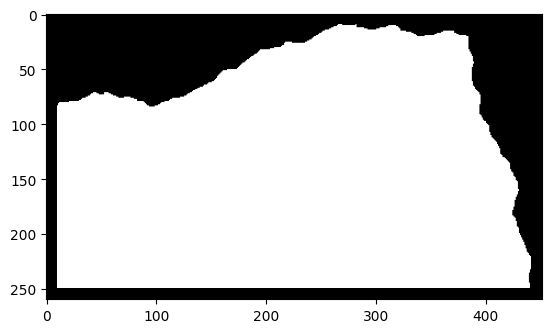

Top :    TORN (variance: 12.93px)
Bottom : TORN (variance: 54.86px)
Left :   TORN (avg: 55.72px)
Right :  STRAIGHT (avg: 0.00px)
TOP Distances[30, 29, 29, 29, 29, 29, 30, 30, 30, 30, 30, 30, 30, 29, 29, 28, 28, 27, 27, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 25, 25, 24, 24, 24, 23, 24, 24, 25, 25, 26, 26, 27, 27, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 27, 28, 28, 29, 30, 30, 31, 31, 32, 32, 33, 33, 34, 34, 35, 35, 36, 36, 37, 38, 38, 39, 39, 40, 40, 40, 40, 40, 40, 40, 41, 41, 42, 42, 43, 44, 45, 45, 45, 46, 47, 48, 48, 48, 48, 48, 48, 48, 48, 48, 47, 47, 47, 46, 46, 46, 46, 46, 47, 47, 47, 46, 46, 46, 45, 45, 45, 45, 45, 44, 44, 43, 42, 42, 41, 41, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 43, 43, 44, 44, 45, 45, 45, 46, 46, 47, 47, 47, 47, 47, 47, 47, 47, 46, 46, 45, 44, 43, 42, 41, 41, 40, 40, 40, 40, 40, 39, 39, 38, 37, 36, 35, 34, 33, 32, 31, 31, 30, 30, 30, 30, 30, 30, 29, 28, 28, 27, 27, 26, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 26, 25, 25, 24, 23, 22, 21, 2

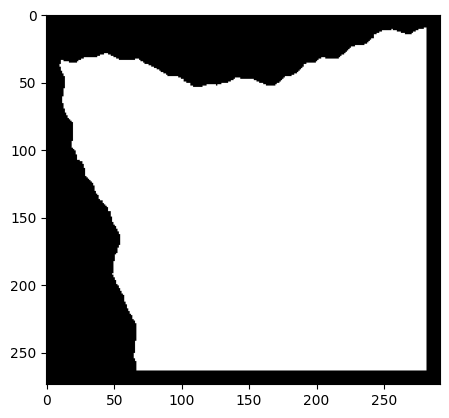

Top :    TORN (variance: 41.40px)
Bottom : TORN (variance: 13.02px)
Left :   TORN (avg: 27.80px)
Right :  TORN (avg: 31.49px)
TOP Distances[162, 160, 158, 157, 155, 152, 149, 147, 145, 144, 139, 134, 132, 130, 128, 127, 126, 124, 122, 120, 118, 117, 115, 114, 113, 112, 111, 110, 104, 101, 97, 94, 92, 90, 88, 87, 86, 84, 82, 80, 78, 77, 75, 55, 51, 49, 23, 18, 15, 13, 9, 6, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 

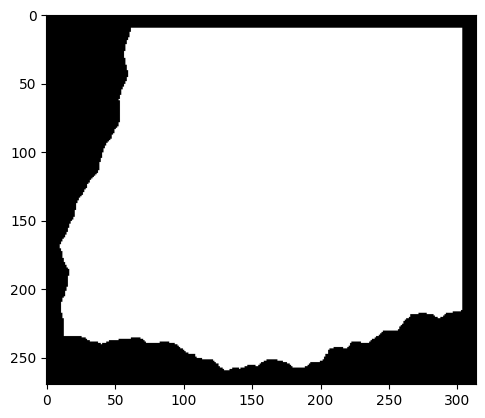

Top :    STRAIGHT (variance: 0.20px)
Bottom : TORN (variance: 56.84px)
Left :   TORN (avg: 10.25px)
Right :  TORN (avg: 94.80px)
BOTTOM Distances[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 12, 12, 13, 14, 14, 15, 16, 17, 17, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 19, 19, 19, 19, 18, 18, 18, 17, 17, 17, 16, 16, 15, 15, 14, 14, 13, 13, 13, 14, 14, 14, 14, 14, 13, 13, 13, 13, 12, 12, 12, 12, 12, 11, 11, 10, 10, 9, 9, 9, 8, 6, 5, 5, 5, 5, 5, 5, 5, 6, 7, 7, 8, 8, 8, 9, 9, 10, 10, 10, 11, 11, 12, 12, 12, 11, 11, 11, 11, 12, 13, 13, 14, 15, 16, 16, 16, 17, 18, 18, 19, 19, 19, 19, 19, 19, 19, 20, 22, 23, 24, 25, 25, 25, 26, 26, 26, 26, 27, 28, 29, 30, 30, 31, 32, 32, 33, 34, 35, 36, 36, 36, 36, 36, 36, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 39, 40, 42, 43, 44, 45, 46, 46, 47, 47, 49, 50, 51, 52, 53, 54, 54, 55, 55, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 57, 57, 58, 58, 58, 59, 60, 61, 62, 62, 62, 62, 62, 62, 61, 61, 61, 61, 61, 61, 61, 61

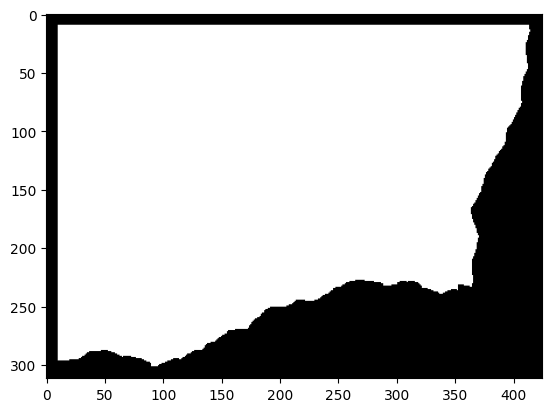

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r'Z:\Internship\Tasks\Edge Detection\image\img1.png'
image = cv2.imread(image_path)

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray_image, (3,3), 0)

_, thresh_init = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY) 

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closed = cv2.morphologyEx(thresh_init, cv2.MORPH_CLOSE, kernel)
contours, hierarchy = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

min_area = 500 
valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]

t,b,l,r=[],[],[],[]

con = []  
for contour in valid_contours: 
    x, y, w, h = cv2.boundingRect(contour)
    pad = 0
    
    x_start, x_end = max(0, x - pad), min(image.shape[1], x + w + pad)
    y_start, y_end = max(0, y - pad), min(image.shape[0], y + h + pad)
    
    cropped_piece = image[y_start:y_end, x_start:x_end]
    
    mask = np.zeros_like(closed)
    cv2.drawContours(mask, [contour], -1, 255, -1) 

    cropped_mask = mask[y_start:y_end, x_start:x_end]
    isolated_piece = cv2.bitwise_and(cropped_piece, cropped_piece, mask=cropped_mask)
    
    con.append(isolated_piece) 

for current_piece in con: 
    padded_image = cv2.copyMakeBorder(current_piece, 10, 10, 10, 10, borderType=cv2.BORDER_CONSTANT, value=[0,0,0])
    
    gray = cv2.cvtColor(padded_image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    
    points = cv2.findNonZero(thresh)
    
    x_box, y_box, w_box, h_box = cv2.boundingRect(points)

    tol = 1.5 
    top_deviations, bottom_deviations = [], []

    for col in range(x_box, x_box + w_box):
        white_pixels = np.where(thresh[:, col] == 255)[0]
        if len(white_pixels) > 0:
            top_deviations.append(int(white_pixels[0] - y_box))
            bottom_deviations.append(int((y_box + h_box) - white_pixels[-1]))

    std_top = np.std(top_deviations) if top_deviations else 0
    std_bottom = np.std(bottom_deviations) if bottom_deviations else 0
    
    top_is_torn = std_top > tol
    bottom_is_torn = std_bottom > tol
    
    print(f"Top :    {'TORN' if top_is_torn else 'STRAIGHT'} (variance: {std_top:.2f}px)")
    print(f"Bottom : {'TORN' if bottom_is_torn else 'STRAIGHT'} (variance: {std_bottom:.2f}px)")

    left_avg, right_avg = [], []
    for row in range(y_box, y_box + h_box):
        white_pixels = np.where(thresh[row, :] == 255)[0]
        if len(white_pixels) > 0:
            left_avg.append(int(white_pixels[0] - x_box))
            right_avg.append(int((x_box + w_box) - white_pixels[-1]))

    std_left = np.std(left_avg) if left_avg else 0
    std_right = np.std(right_avg) if right_avg else 0
    
    left_is_torn = std_left > tol
    right_is_torn = std_right > tol
    
    print(f"Left :   {'TORN' if left_is_torn else 'STRAIGHT'} (avg: {std_left:.2f}px)")
    print(f"Right :  {'TORN' if right_is_torn else 'STRAIGHT'} (avg: {std_right:.2f}px)")

    a1 = cv2.Canny(thresh, 150, 150)
    y_arr, x_arr = np.where(a1 == 255)
    
    y_pixels, x_pixels = np.where(thresh == 255)
    min_y, max_y = np.min(y_pixels), np.max(y_pixels)
    min_x, max_x = np.min(x_pixels), np.max(x_pixels)
    
    g1 = 5  
    any_torn = False

    if top_is_torn:
        any_torn = True
        b11_top = []
        for col_x in range(min_x, max_x + 1):
            pixels_in_col = y_arr[x_arr == col_x]
            if len(pixels_in_col) > 0:
                b11_top.append((int(col_x), int(np.min(pixels_in_col))))
        
        top_ref_y = int(min_y - g1)
        distances_top = [abs(int(y11) - top_ref_y) for _, y11 in b11_top]
        t.append(distances_top)
        print(f"TOP Distances{distances_top}")
    else:
        t.append(np.nan)    

    if bottom_is_torn:
        any_torn = True
        b11_bottom = []
        for col_x in range(min_x, max_x + 1):
            pixels_in_col = y_arr[x_arr == col_x]
            if len(pixels_in_col) > 0:
                b11_bottom.append((int(col_x), int(np.max(pixels_in_col))))
        
        bottom_ref_y = int(max_y + g1)
        distances_bottom = [abs(int(y11) - bottom_ref_y) for _, y11 in b11_bottom]
        b.append(distances_bottom)
        print(f"BOTTOM Distances{distances_bottom}")
    else:
         b.append(np.nan)    


    if left_is_torn:
        any_torn = True
        b11_left = []
        for row_y in range(min_y, max_y + 1):
            pixels_in_row = x_arr[y_arr == row_y]
            if len(pixels_in_row) > 0:
                b11_left.append((int(row_y), int(np.min(pixels_in_row))))
        
        left_ref_x = int(min_x - g1)
        distances_left = [abs(int(x11) - left_ref_x) for _, x11 in b11_left]
        l.append(distances_left)
        print(f"LEFT Distances {distances_left}")
    else:
          l.append(np.nan)    


    if right_is_torn:
        any_torn = True
        b11_right = []
        for row_y in range(min_y, max_y + 1):
            pixels_in_row = x_arr[y_arr == row_y]
            if len(pixels_in_row) > 0:
                b11_right.append((int(row_y), int(np.max(pixels_in_row))))
        
        right_ref_x = int(max_x + g1)
        distances_right = [abs(int(x11) - right_ref_x) for _, x11 in b11_right]
        r.append(distances_right)
        print(f"RIGHT Distances{distances_right}")
    else:
         r.append(np.nan)
    
    plt.imshow(thresh, cmap='gray')
    plt.show()

In [3]:
side1 = b[3]
side2 = t[0]
print(side1)
print(side2)
th = 0.82
tr = 12

edge1 = np.array(side1 if len(side1) > 2*tr else side1, dtype=float)
edge2 = np.array(side2 if len(side2) > 2*tr else side2, dtype=float)

x1 = np.arange(len(edge1))
slope1, intercept1 = np.polyfit(x1, edge1, 1)
detrended1 = edge1 - (slope1 * x1 + intercept1)
roughness1 = np.std(detrended1)

x2 = np.arange(len(edge2))
slope2, intercept2 = np.polyfit(x2, edge2, 1)
detrended2 = edge2 - (slope2 * x2 + intercept2)
roughness2 = np.std(detrended2)

if roughness1 < 1.2 or roughness2 < 1.2:
    print("NOT MATCHED ")
  

else:
    norm1 = (edge1 - np.min(edge1)) / (np.max(edge1) - np.min(edge1) + 1e-6)
    norm2 = (edge2 - np.min(edge2)) / (np.max(edge2) - np.min(edge2) + 1e-6)

    if len(norm1) < len(norm2):
        shorter, longer = norm1, norm2
        is1_shorter = True
    else:
        shorter, longer = norm2, norm1
        is1_shorter = False
        
    s_len, l_len = len(shorter), len(longer)

    best_score = 0.0
    best_offset = 0

    for direction in ["Forward", "Reversed"]:
        test_shorter = shorter if direction == "Forward" else shorter[::-1]
        
        for offset in range(l_len - s_len + 1):
            segment = longer[offset:offset + s_len]
            
            dist_direct = np.mean(np.abs(test_shorter - segment))
            score_direct = 1.0 - dist_direct
            
            dist_comp = np.mean(np.abs(test_shorter - (1.0 - segment)))
            score_comp = 1.0 - dist_comp
            
            if score_direct > best_score:
                best_score = score_direct
                best_offset = offset if is1_shorter else -offset
                
            if score_comp > best_score:
                best_score = score_comp
                best_offset = offset if is1_shorter else -offset

    confidence = best_score * 100

    if best_score >= th:
        print("MATCHED ")
        print(f"Confidence Score: {confidence:.2f}%")
    else:
        print("NOT MATCHED ")
        print(f"Confidence Score: {confidence:.2f}%")

[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 12, 12, 13, 14, 14, 15, 16, 17, 17, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 19, 19, 19, 19, 18, 18, 18, 17, 17, 17, 16, 16, 15, 15, 14, 14, 13, 13, 13, 14, 14, 14, 14, 14, 13, 13, 13, 13, 12, 12, 12, 12, 12, 11, 11, 10, 10, 9, 9, 9, 8, 6, 5, 5, 5, 5, 5, 5, 5, 6, 7, 7, 8, 8, 8, 9, 9, 10, 10, 10, 11, 11, 12, 12, 12, 11, 11, 11, 11, 12, 13, 13, 14, 15, 16, 16, 16, 17, 18, 18, 19, 19, 19, 19, 19, 19, 19, 20, 22, 23, 24, 25, 25, 25, 26, 26, 26, 26, 27, 28, 29, 30, 30, 31, 32, 32, 33, 34, 35, 36, 36, 36, 36, 36, 36, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 39, 40, 42, 43, 44, 45, 46, 46, 47, 47, 49, 50, 51, 52, 53, 54, 54, 55, 55, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 57, 57, 58, 58, 58, 59, 60, 61, 62, 62, 62, 62, 62, 62, 61, 61, 61, 61, 61, 61, 61, 61, 61, 61, 62, 62, 62, 63, 63, 64, 65, 66, 66, 67, 67, 67, 68, 69, 70, 71, 72, 72, 73, 73, 73, 73, 73, 74, 75, 75, 76, 77, 77, 77, 78, 78, 78, 78,

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r'Z:\Internship\Tasks\Edge Detection\image\img6.jpeg'
image = cv2.imread(image_path)

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray_image, (3,3), 0)

In [5]:
_, thresh_init = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY) 

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closed = cv2.morphologyEx(thresh_init, cv2.MORPH_CLOSE, kernel)
contours, hierarchy = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

min_area = 500 
valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]

t, b, l, r = [], [], [], []
con = []  

In [6]:
con = []  
for contour in valid_contours: 
    x, y, w, h = cv2.boundingRect(contour)
    pad = 0
    
    x_start, x_end = max(0, x - pad), min(image.shape[1], x + w + pad)
    y_start, y_end = max(0, y - pad), min(image.shape[0], y + h + pad)
    
    cropped_piece = image[y_start:y_end, x_start:x_end]
    
    mask = np.zeros_like(closed)
    cv2.drawContours(mask, [contour], -1, 255, -1) 

    cropped_mask = mask[y_start:y_end, x_start:x_end]
    isolated_piece = cv2.bitwise_and(cropped_piece, cropped_piece, mask=cropped_mask)
    
    con.append(isolated_piece)

Top :    TORN (variance: 14.82px)
Bottom : STRAIGHT (variance: 1.39px)
Left :   TORN (avg: 30.18px)
Right :  TORN (avg: 7.38px)
TOP Distances[14, 14, 13, 14, 18, 18, 18, 18, 18, 18, 17, 17, 16, 16, 15, 16, 17, 18, 19, 20, 21, 21, 22, 22, 22, 22, 22, 22, 22, 21, 21, 21, 21, 22, 22, 23, 27, 28, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 28, 28, 27, 27, 27, 27, 26, 26, 26, 25, 25, 24, 23, 23, 22, 22, 21, 21, 21, 21, 21, 21, 21, 21, 21, 20, 19, 18, 18, 17, 16, 16, 15, 15, 14, 14, 13, 13, 13, 13, 12, 12, 12, 11, 11, 11, 11, 11, 11, 11, 11, 11, 10, 9, 8, 7, 7, 6, 6, 5, 5, 4, 4, 4, 5, 5, 6, 7, 8, 8, 8, 8, 8, 8, 8, 8, 7, 7, 7, 7, 8, 9, 11, 12, 13, 14, 15, 19, 36, 40, 42, 43, 45, 46, 66, 68, 69, 70, 71, 73, 79, 84]
LEFT Distances [119, 117, 115, 114, 113, 112, 103, 100, 7, 5, 5, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,

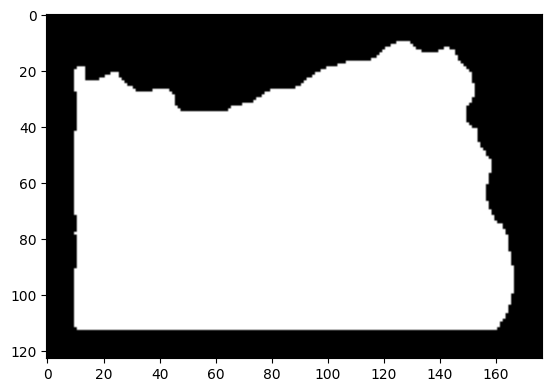

Top :    TORN (variance: 20.93px)
Bottom : TORN (variance: 25.60px)
Left :   TORN (avg: 6.55px)
Right :  TORN (avg: 17.07px)
TOP Distances[5, 5, 5, 6, 8, 9, 10, 10, 10, 10, 10, 11, 11, 12, 12, 12, 12, 12, 12, 12, 11, 10, 10, 9, 9, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 11, 11, 10, 9, 8, 8, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 7, 7, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 9, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 9, 9, 9, 9, 8, 8, 8, 8, 8, 8, 8, 8, 9, 14, 37, 39, 41, 45, 46, 48, 50, 71, 72, 73, 74, 75, 76, 78, 96, 96, 97]
BOTTOM Distances[103, 102, 101, 100, 99, 80, 79, 78, 75, 73, 71, 52, 50, 48, 46, 45, 44, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 9, 10, 12]
LEFT Distances [

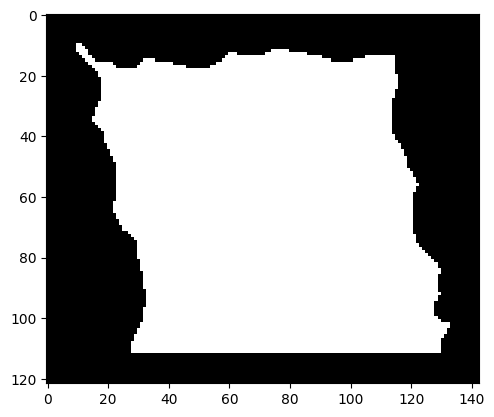

Top :    TORN (variance: 37.77px)
Bottom : TORN (variance: 42.46px)
Left :   TORN (avg: 99.76px)
Right :  TORN (avg: 9.29px)
TOP Distances[135, 133, 120, 119, 118, 119, 119, 120, 121, 121, 122, 122, 123, 123, 123, 123, 123, 123, 122, 122, 121, 121, 121, 121, 121, 120, 119, 118, 117, 104, 102, 102, 101, 101, 100, 99, 98, 96, 96, 95, 96, 97, 98, 99, 100, 101, 101, 101, 101, 101, 101, 102, 102, 102, 102, 102, 103, 103, 105, 106, 108, 111, 112, 112, 112, 112, 112, 112, 112, 112, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 110, 110, 110, 110, 110, 112, 113, 113, 113, 113, 113, 113, 114, 114, 115, 115, 115, 115, 115, 115, 114, 113, 113, 113, 114, 115, 115, 115, 115, 115, 115, 115, 115, 115, 115, 115, 115, 115, 115, 115, 115, 115, 115, 114, 114, 113, 113, 111, 110, 109, 109, 109, 109, 109, 109, 102, 100, 100, 99, 99, 99, 99, 99, 99, 98, 97, 96, 95, 93, 93, 92, 92, 92, 92, 92, 91, 89, 88, 87, 87, 86, 86, 85, 85, 84, 84, 83, 83, 83, 83, 83, 83, 84, 84, 85, 85, 85,

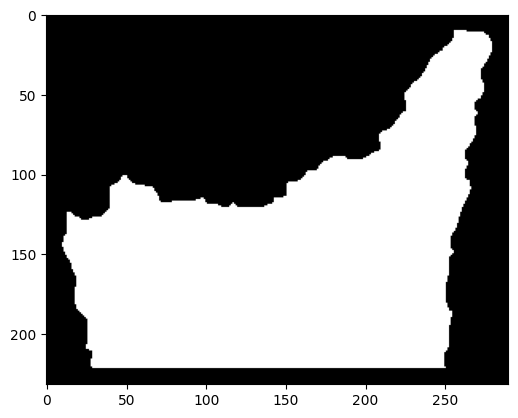

Top :    TORN (variance: 43.38px)
Bottom : STRAIGHT (variance: 0.15px)
Left :   TORN (avg: 38.52px)
Right :  STRAIGHT (avg: 0.23px)
TOP Distances[207, 203, 189, 177, 174, 172, 171, 170, 165, 162, 159, 135, 122, 120, 119, 118, 116, 100, 92, 90, 89, 89, 70, 68, 43, 42, 42, 42, 42, 42, 41, 41, 40, 40, 39, 39, 39, 38, 38, 38, 37, 36, 36, 35, 35, 34, 34, 34, 34, 34, 34, 35, 35, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 35, 35, 34, 34, 33, 32, 32, 31, 31, 31, 30, 29, 28, 28, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 26, 26, 25, 25, 25, 25, 25, 24, 24, 23, 23, 23, 23, 24, 24, 25, 26, 26, 27, 27, 27, 27, 27, 27, 27, 27, 27, 26, 26, 26, 27, 27, 27, 27, 27, 27, 27, 27, 26, 26, 25, 25, 25, 24, 24, 17, 16, 15, 15, 15, 14, 14, 14, 12, 11, 11, 11, 11, 11, 11, 11, 11, 11, 9, 9, 9, 10, 10, 10, 10, 10, 10, 9, 7, 6, 6, 5, 5, 5, 5, 5, 5, 6, 7]
LEFT Distances [172, 170, 169, 169, 159, 159, 150, 149, 149, 146, 143, 142, 141, 141, 141, 141, 141, 141, 105, 103, 98, 96, 84, 82, 81, 80, 77, 75, 74,

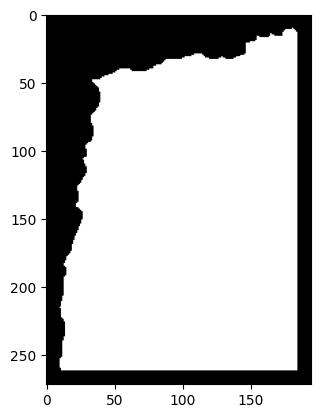

Top :    TORN (variance: 50.37px)
Bottom : TORN (variance: 8.03px)
Left :   TORN (avg: 6.63px)
Right :  TORN (avg: 38.04px)
TOP Distances[6, 5, 4, 4, 5, 5, 5, 6, 6, 8, 17, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 19, 19, 27, 28, 29, 29, 30, 30, 30, 30, 30, 31, 31, 32, 32, 33, 33, 33, 33, 33, 34, 34, 37, 48, 50, 51, 51, 51, 51, 51, 51, 51, 51, 51, 50, 50, 50, 50, 50, 50, 50, 50, 51, 62, 63, 64, 65, 66, 66, 67, 67, 68, 68, 69, 69, 69, 69, 69, 69, 70, 74, 75, 76, 76, 77, 78, 78, 79, 79, 79, 80, 80, 81, 81, 81, 81, 82, 86, 88, 89, 90, 91, 91, 91, 92, 92, 93, 94, 97, 119, 121, 122, 125, 127, 129, 131, 161, 162, 163, 163, 164, 165, 165, 166, 166, 167, 168, 168, 170, 183, 184, 185, 186, 187]
BOTTOM Distances[21, 20, 20, 19, 16, 15, 15, 15, 15, 15, 16, 17, 17, 17, 17, 17, 17, 16, 15, 14, 12, 12, 12, 12, 12, 12, 12, 11, 11, 11, 11, 11, 11, 11, 11, 11, 10, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 7, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 10, 11, 12, 12, 13, 13, 13, 13, 13, 13, 1

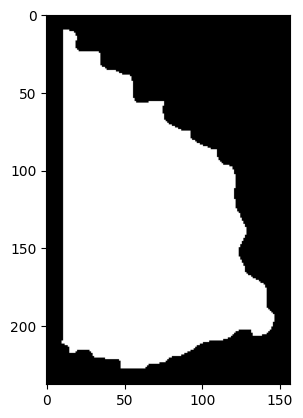

Top :    TORN (variance: 37.37px)
Bottom : TORN (variance: 60.30px)
Left :   TORN (avg: 39.89px)
Right :  TORN (avg: 54.89px)
TOP Distances[165, 163, 162, 161, 159, 157, 156, 152, 150, 149, 149, 148, 147, 147, 146, 145, 144, 143, 141, 140, 138, 136, 121, 117, 115, 114, 113, 112, 27, 25, 25, 24, 24, 23, 23, 22, 22, 22, 23, 23, 24, 25, 25, 26, 26, 27, 27, 28, 28, 29, 29, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 29, 29, 29, 28, 27, 27, 26, 26, 25, 25, 24, 24, 24, 24, 23, 23, 22, 22, 22, 21, 20, 19, 17, 16, 15, 14, 14, 14, 14, 14, 14, 14, 14, 13, 12, 12, 11, 11, 11, 11, 11, 11, 12, 12, 12, 13, 13, 14, 14, 15, 16, 17, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 18, 18, 18, 18, 19, 20, 21, 22, 22, 22, 21, 17, 15, 15, 14, 14, 14, 14, 14, 14, 15, 15, 18, 19, 20, 21, 21, 21, 21, 22, 22, 23, 23, 24, 24, 24, 24, 24, 24, 24, 23, 18, 16, 16, 15, 15, 15, 14, 14, 14, 14, 14, 13, 13, 13, 13, 12, 12, 13, 13, 14, 15, 17, 19, 20, 21, 22, 22, 22, 22, 22, 22, 22, 22, 21, 19, 18, 17, 17, 16, 16, 17, 17, 

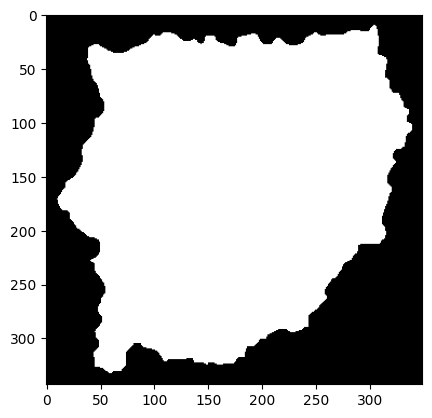

Top :    TORN (variance: 13.78px)
Bottom : TORN (variance: 27.80px)
Left :   TORN (avg: 9.32px)
Right :  TORN (avg: 41.53px)
TOP Distances[9, 9, 10, 10, 11, 11, 11, 11, 11, 11, 7, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 9, 9, 10, 10, 10, 11, 11, 11, 12, 12, 13, 13, 14, 14, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 17, 17, 17, 17, 17, 17, 17, 17, 16, 16, 16, 15, 15, 15, 15, 14, 14, 15, 16, 18, 19, 20, 20, 21, 21, 22, 23, 23, 24, 24, 25, 25, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 25, 25, 24, 24, 24, 23, 24, 24, 29, 30, 31, 31, 31, 31, 31, 31, 30, 30, 30, 31, 32, 33, 34, 35, 35, 36, 38, 40, 42, 44, 45, 45, 45, 45, 45, 45, 45, 45, 47, 49, 49, 50, 50, 50, 50, 50, 51, 51, 52, 52, 53, 53, 54]
BOTTOM Distances[183, 182, 182, 181, 24, 5, 8, 5, 6, 6, 7, 8, 9, 9, 10, 10, 10, 11, 11, 12, 12, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 13, 13, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 14, 14, 14, 14, 15, 15, 16, 16, 16, 16, 16, 18, 19, 20, 21, 21, 22, 22, 22, 22, 21

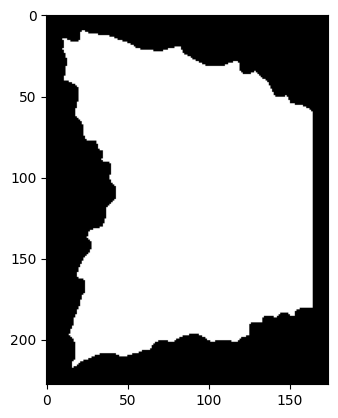

Top :    TORN (variance: 23.42px)
Bottom : TORN (variance: 75.16px)
Left :   TORN (avg: 54.63px)
Right :  TORN (avg: 28.64px)
TOP Distances[16, 15, 15, 14, 13, 13, 12, 12, 11, 11, 11, 11, 11, 11, 12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 12, 12, 11, 11, 10, 9, 8, 8, 7, 7, 7, 6, 6, 6, 6, 5, 5, 5, 5, 6, 7, 8, 9, 10, 11, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 12, 11, 10, 9, 7, 6, 6, 5, 6, 6, 7, 9, 10, 10, 11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 11, 11, 10, 10, 10, 10, 10, 9, 9, 10, 10, 10, 11, 11, 12, 12, 14, 15, 16, 17, 18, 18, 19, 19, 19, 19, 19, 19, 19, 18, 18, 18, 18, 18, 18, 18, 17, 16, 16, 15, 14, 13, 13, 12, 12, 11, 11, 11, 11, 12, 12, 13, 13, 13, 14, 14, 15, 17, 18, 19, 20, 20, 20, 20, 20, 20, 19, 18, 17, 17, 16, 17, 17, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 17, 17, 17, 17, 17, 16, 16, 16, 17, 17, 18, 20, 22, 23, 23, 23, 23, 23, 23, 23, 22, 23, 23, 24, 25, 25, 26, 26, 2

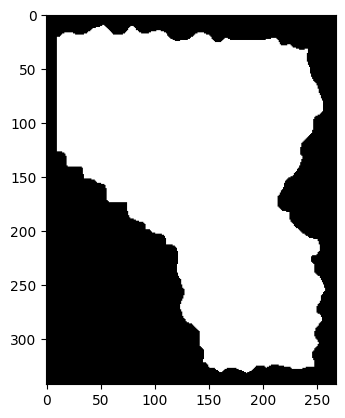

Top :    TORN (variance: 17.98px)
Bottom : TORN (variance: 14.58px)
Left :   TORN (avg: 50.73px)
Right :  TORN (avg: 40.48px)
TOP Distances[91, 89, 85, 77, 75, 74, 73, 72, 56, 54, 53, 52, 51, 49, 48, 46, 6, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 8, 9, 9, 9, 9, 10, 10, 15, 17, 18, 19, 19, 20, 20, 20, 20, 20, 20, 20, 19, 19, 18, 18, 18, 17, 17, 16, 16, 15, 15, 15, 15, 15, 16, 16, 23, 24, 25, 25, 25, 25, 25, 26, 26, 27, 27, 27, 27, 27, 27, 28, 28, 29, 29, 30, 30, 32, 34, 34, 34, 35, 35, 36, 37, 37, 38, 38, 37, 35, 34, 33, 34, 34, 34, 35, 35, 35, 35, 35, 35, 35, 35, 36, 36, 36, 36, 36, 36, 36, 36, 37, 37, 38, 38, 39, 40, 41, 42, 42, 43, 43, 43, 43, 43, 43, 43, 43, 43, 42, 42, 43, 44, 45, 45, 45, 45, 41, 41, 41, 42, 43, 44, 44, 44, 44, 44, 44, 44, 45]
BOTTOM Distances[73, 72, 71, 58, 52, 50, 48, 48, 48, 48, 48, 48, 48, 48, 48, 47, 47, 47, 46, 45, 45, 45, 50, 51, 52, 52, 52, 52, 52, 51, 51, 51, 51, 51, 51, 51, 51, 50, 50, 50, 50, 50, 50, 49, 48, 48, 47, 47, 47, 47, 46, 4

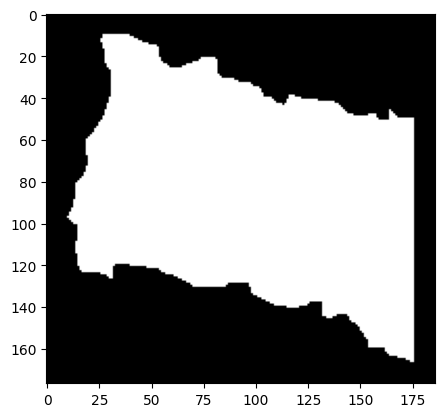

Top :    TORN (variance: 37.38px)
Bottom : TORN (variance: 5.26px)
Left :   TORN (avg: 71.48px)
Right :  TORN (avg: 11.83px)
TOP Distances[69, 68, 68, 68, 67, 67, 67, 68, 68, 68, 68, 69, 69, 70, 70, 70, 70, 70, 70, 69, 68, 67, 66, 66, 65, 65, 64, 64, 65, 65, 65, 65, 65, 65, 65, 65, 64, 62, 60, 60, 59, 59, 58, 58, 58, 57, 57, 56, 56, 55, 55, 54, 54, 54, 54, 54, 53, 53, 52, 52, 53, 53, 53, 53, 53, 53, 53, 53, 53, 53, 53, 53, 52, 52, 51, 50, 50, 49, 49, 49, 48, 48, 48, 48, 48, 49, 49, 49, 49, 49, 49, 49, 49, 49, 48, 48, 47, 46, 45, 44, 43, 41, 40, 40, 39, 38, 38, 37, 37, 37, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 35, 35, 35, 35, 34, 34, 34, 34, 33, 33, 32, 32, 32, 31, 31, 31, 31, 30, 30, 30, 30, 30, 30, 30, 29, 28, 27, 26, 25, 24, 22, 21, 21, 20, 20, 20, 19, 15, 13, 13, 12, 12, 11, 11, 11, 11, 11, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 12, 12, 11, 9, 7, 5, 5, 5, 5, 6, 22, 23, 24, 25, 26, 30, 58, 60, 64, 103, 130, 131, 131, 131, 132, 132, 133, 140,

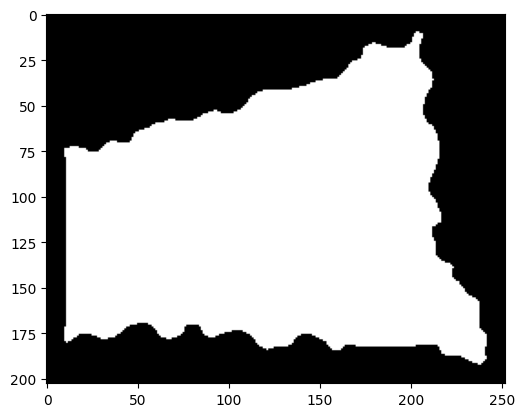

Top :    TORN (variance: 34.11px)
Bottom : TORN (variance: 27.19px)
Left :   TORN (avg: 39.57px)
Right :  TORN (avg: 46.79px)
TOP Distances[91, 87, 85, 83, 82, 80, 79, 78, 77, 73, 71, 71, 70, 70, 70, 70, 70, 69, 69, 69, 69, 69, 69, 70, 70, 71, 71, 72, 73, 74, 74, 74, 75, 75, 75, 75, 75, 75, 75, 75, 74, 73, 73, 72, 72, 72, 72, 72, 69, 68, 67, 67, 67, 67, 67, 67, 66, 66, 67, 67, 68, 68, 69, 69, 69, 69, 69, 69, 69, 69, 68, 67, 65, 64, 62, 54, 53, 52, 52, 51, 50, 49, 48, 48, 47, 47, 46, 46, 46, 46, 45, 45, 45, 44, 44, 43, 43, 43, 43, 43, 43, 43, 39, 37, 37, 36, 36, 36, 33, 30, 26, 14, 11, 9, 8, 7, 7, 7, 7, 8, 9, 10, 14, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 15, 15, 14, 14, 13, 12, 11, 10, 8, 7, 7, 6, 7, 7, 9, 9, 9, 9, 9, 9, 9, 8, 8, 8, 7, 7, 7, 6, 6, 6, 6, 5, 5, 4, 4, 4, 5, 5, 6, 6, 7, 8, 9, 10, 10, 10, 11, 11, 12, 12, 13, 13, 13, 13, 13, 13, 13, 14, 15, 16, 17, 18, 19, 20, 21, 24, 25, 26, 27, 27, 28, 28, 28, 29, 29, 30, 30, 32, 43, 44, 45, 45, 46, 46, 46,

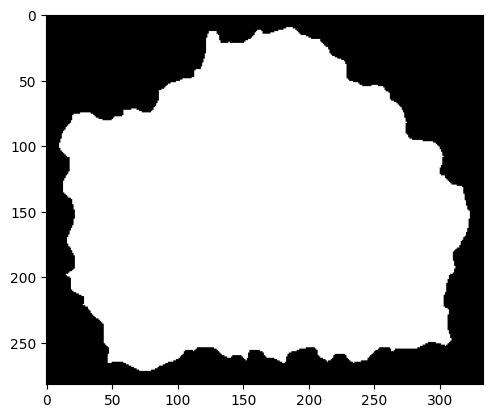

Top :    TORN (variance: 18.45px)
Bottom : TORN (variance: 22.44px)
Left :   TORN (avg: 6.20px)
Right :  TORN (avg: 33.31px)
TOP Distances[25, 22, 20, 17, 15, 14, 13, 6, 5, 5, 5, 5, 5, 6, 6, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 7, 7, 6, 6, 5, 6, 6, 11, 14, 15, 16, 16, 16, 16, 16, 16, 16, 16, 17, 17, 18, 18, 18, 19, 19, 20, 20, 20, 21, 21, 22, 22, 24, 24, 24, 24, 24, 24, 23, 21, 19, 17, 17, 17, 18, 19, 20, 20, 21, 28, 30, 30, 30, 30, 30, 31, 32, 33, 33, 34, 34, 39, 41, 42, 43, 43, 44, 55, 56, 57, 57, 57, 57, 57, 57, 57, 57, 56, 57, 57, 58, 58, 58, 58, 58, 58, 58, 57, 56, 55, 55, 54, 54, 53, 52, 51, 50, 50, 49, 49, 48, 47, 47]
BOTTOM Distances[93, 91, 89, 88, 88, 87, 86, 85, 82, 80, 79, 66, 27, 25, 24, 22, 20, 5, 7, 5, 6, 7, 8, 9, 11, 14, 15, 16, 17, 17, 18, 18, 18, 18, 19, 19, 19, 19, 19, 18, 18, 17, 17, 16, 15, 14, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 14, 15, 15, 15, 15, 15, 15, 19, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 20, 20, 19, 18, 17, 17, 17, 17, 18, 19, 21, 22, 24, 25, 

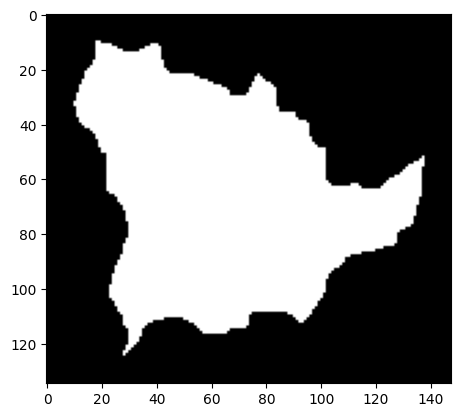

Top :    TORN (variance: 22.15px)
Bottom : TORN (variance: 19.36px)
Left :   TORN (avg: 24.05px)
Right :  TORN (avg: 49.66px)
TOP Distances[59, 57, 56, 54, 53, 52, 51, 51, 50, 50, 50, 50, 50, 50, 50, 50, 49, 43, 41, 39, 39, 38, 38, 37, 37, 36, 36, 35, 35, 35, 35, 34, 34, 34, 34, 34, 34, 34, 34, 33, 33, 32, 32, 32, 32, 32, 32, 32, 31, 31, 31, 31, 30, 30, 29, 29, 29, 29, 29, 29, 29, 29, 28, 27, 20, 19, 18, 18, 18, 17, 17, 16, 16, 15, 15, 14, 14, 14, 13, 13, 13, 13, 11, 7, 5, 5, 4, 4, 4, 4, 4, 5, 6, 8, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 14, 14, 14, 14, 14, 14, 14, 13, 12, 12, 11, 11, 12, 13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 16, 16, 17, 18, 19, 20, 21, 21, 21, 21, 21, 22, 22, 22, 22, 22, 22, 22, 23, 23, 24, 24, 27, 30, 30, 30, 30, 30, 30, 30, 30, 31, 32, 71, 72, 73, 86, 88, 89, 90, 91, 93, 135, 137]
BOTTOM Distances[10, 9, 9, 9, 9, 9, 9, 9, 9, 8, 8, 7, 7, 7, 6, 6, 5, 5, 5,

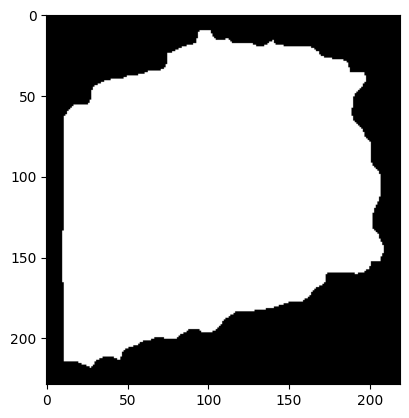

Top :    TORN (variance: 34.49px)
Bottom : TORN (variance: 38.64px)
Left :   TORN (avg: 62.87px)
Right :  TORN (avg: 16.46px)
TOP Distances[85, 83, 81, 81, 80, 80, 80, 80, 79, 79, 78, 78, 78, 78, 78, 77, 77, 77, 76, 75, 74, 73, 70, 63, 61, 60, 59, 58, 57, 56, 54, 52, 51, 50, 48, 45, 40, 38, 31, 30, 29, 29, 29, 29, 28, 28, 27, 27, 27, 27, 26, 26, 26, 25, 25, 25, 24, 22, 20, 19, 17, 16, 15, 15, 14, 14, 14, 13, 14, 14, 15, 16, 17, 18, 18, 19, 19, 19, 19, 19, 19, 19, 18, 18, 18, 17, 17, 16, 15, 15, 14, 14, 14, 13, 13, 13, 13, 13, 14, 14, 15, 15, 16, 17, 18, 18, 18, 18, 18, 18, 18, 17, 17, 18, 18, 18, 18, 18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 18, 18, 17, 17, 17, 17, 16, 15, 14, 13, 12, 12, 11, 11, 11, 11, 10, 10, 10, 10, 10, 10, 9, 8, 7, 6, 5, 5, 5, 5, 8, 23, 24, 25, 26, 26, 31, 33, 34, 35, 41, 51, 52, 53, 58, 67, 68, 69, 70, 73, 75, 77, 81, 82, 83, 84, 90, 92, 95, 96, 108, 109, 110, 111, 112, 113, 114, 114, 114, 114, 114, 114, 114, 114, 113, 113, 113, 113, 113, 112, 1

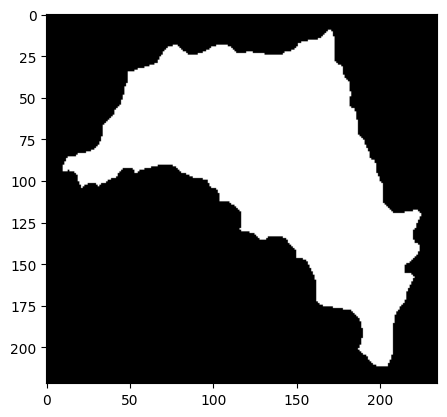

Top :    TORN (variance: 10.62px)
Bottom : TORN (variance: 67.47px)
Left :   TORN (avg: 40.51px)
Right :  TORN (avg: 4.53px)
TOP Distances[44, 43, 42, 41, 41, 40, 40, 40, 39, 36, 34, 32, 30, 29, 29, 28, 28, 28, 28, 28, 28, 28, 29, 29, 29, 30, 30, 30, 30, 30, 30, 30, 29, 29, 29, 29, 29, 29, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 27, 27, 26, 26, 26, 26, 27, 29, 30, 30, 31, 31, 31, 32, 32, 33, 37, 38, 39, 39, 39, 39, 40, 40, 40, 40, 40, 40, 40, 39, 39, 39, 38, 37, 36, 36, 36, 36, 35, 35, 35, 34, 34, 34, 33, 32, 31, 31, 30, 30, 30, 30, 29, 28, 28, 27, 27, 27, 26, 26, 26, 27, 27, 27, 27, 27, 27, 27, 27, 26, 26, 25, 25, 24, 24, 24, 24, 23, 23, 22, 22, 11, 11, 12, 12, 12, 12, 12, 12, 12, 11, 10, 10, 9, 9, 8, 7, 6, 5, 5, 4, 5, 5, 6, 6, 7, 7, 8, 9, 10, 11, 11, 11, 11, 11, 11, 10, 11, 11, 11, 11, 12, 12, 12, 13, 13, 13, 13, 13, 13, 14, 14, 14, 14, 15]
BOTTOM Distances[247, 232, 230, 229, 229, 228, 224, 222, 221, 220, 204, 203, 202, 201, 199, 189, 187, 185, 184, 183, 182, 178, 174, 172, 171, 170

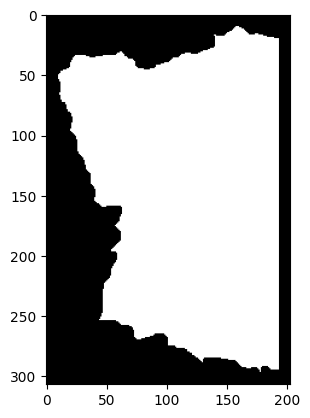

Top :    TORN (variance: 6.89px)
Bottom : TORN (variance: 12.79px)
Left :   STRAIGHT (avg: 0.00px)
Right :  TORN (avg: 25.68px)
TOP Distances[5, 4, 4, 4, 4, 4, 5, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 8, 8, 7, 7, 7, 7, 7, 7, 6, 6, 6, 6, 6, 8, 9, 10, 11, 11, 11, 12, 12, 13, 13, 13, 13, 13, 13, 13, 12, 12, 12, 13, 14, 15, 15, 15, 15, 15, 15, 16, 23, 24, 24, 24, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 24, 25, 25]
BOTTOM Distances[5, 5, 6, 7, 8, 9, 9, 10, 11, 11, 11, 11, 10, 10, 10, 11, 12, 20, 21, 22, 23, 23, 24, 24, 24, 25, 25, 26, 26, 26, 26, 26, 26, 26, 26, 26, 27, 27, 28, 28, 28, 28, 29, 29, 29, 29, 29, 29, 29, 30, 30, 31, 31, 32, 32, 32, 32, 32, 32, 32, 33, 33, 33, 36, 40, 41, 42, 43, 43, 44, 44, 45, 45, 46, 46, 47, 47, 47, 47, 48, 48, 52, 55, 56]
RIGHT Distances[80, 49, 49, 48, 47, 46, 43, 31, 30, 29, 23, 22, 22, 22, 22, 22, 22, 22, 21, 7, 5, 5, 5, 6, 7, 7, 7, 8, 8, 8, 8, 10, 14, 16, 18, 20, 22, 23, 24, 25, 25, 25, 25, 26, 26, 26, 29, 36, 38, 40, 47, 51, 53, 62

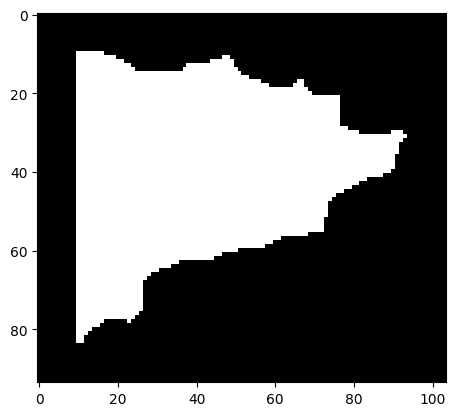

Top :    TORN (variance: 30.79px)
Bottom : TORN (variance: 6.49px)
Left :   TORN (avg: 28.21px)
Right :  TORN (avg: 3.94px)
TOP Distances[101, 101, 101, 100, 99, 98, 97, 96, 95, 93, 91, 89, 88, 87, 86, 85, 84, 79, 77, 74, 72, 70, 68, 57, 56, 55, 55, 55, 55, 55, 54, 53, 51, 49, 47, 43, 40, 39, 38, 38, 38, 38, 38, 38, 37, 36, 36, 35, 34, 33, 32, 31, 30, 28, 27, 26, 24, 22, 21, 20, 20, 20, 20, 20, 19, 18, 18, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 16, 15, 15, 14, 13, 12, 9, 7, 5, 5, 5, 6, 7, 28, 29, 45, 46, 48, 50, 62, 63, 65, 110, 110, 111]
BOTTOM Distances[32, 32, 34, 35, 32, 30, 28, 27, 26, 26, 26, 26, 26, 27, 27, 27, 26, 24, 24, 24, 25, 25, 25, 25, 25, 25, 25, 24, 24, 24, 24, 24, 24, 23, 23, 23, 23, 23, 24, 25, 25, 25, 24, 24, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 21, 20, 19, 17, 16, 16, 16, 16, 16, 16, 16, 15, 15, 15, 15, 15, 15, 14, 14, 13, 12, 12, 7, 5, 5, 5, 5, 5, 6, 6, 8, 12, 14, 16, 22]
LEFT Distances [92, 92, 91, 91

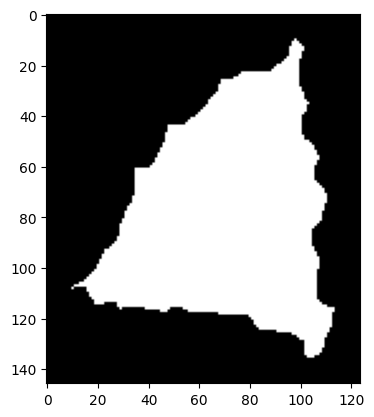

Top :    TORN (variance: 49.25px)
Bottom : TORN (variance: 10.76px)
Left :   TORN (avg: 14.17px)
Right :  TORN (avg: 40.02px)
TOP Distances[166, 165, 165, 165, 165, 164, 163, 162, 161, 161, 160, 159, 157, 151, 149, 148, 146, 144, 143, 141, 135, 134, 82, 80, 79, 78, 78, 77, 76, 75, 72, 70, 19, 13, 9, 7, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5]
BOTTOM Distances[30, 29, 29, 28, 27, 26, 24, 23, 21, 16, 13, 5, 55, 5, 6, 8, 9, 10, 11, 11, 11, 11, 15, 17, 19, 20, 21, 22, 22, 23, 23, 23, 23, 23, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 21, 20, 20, 20, 21, 2

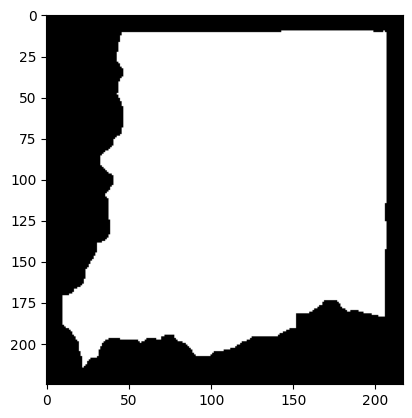

Top :    TORN (variance: 41.24px)
Bottom : TORN (variance: 49.29px)
Left :   TORN (avg: 55.69px)
Right :  TORN (avg: 67.36px)
TOP Distances[129, 129, 128, 127, 127, 126, 126, 125, 125, 125, 120, 119, 118, 118, 115, 113, 113, 112, 112, 111, 111, 111, 111, 110, 109, 108, 107, 107, 106, 105, 104, 103, 102, 101, 100, 100, 99, 99, 98, 98, 98, 97, 97, 96, 96, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 94, 93, 92, 91, 90, 90, 89, 89, 89, 89, 88, 88, 88, 88, 88, 89, 89, 89, 89, 89, 89, 89, 89, 88, 87, 86, 85, 83, 81, 79, 78, 76, 75, 74, 73, 73, 72, 72, 71, 70, 69, 67, 65, 63, 59, 57, 56, 55, 55, 54, 53, 52, 50, 50, 49, 48, 47, 47, 46, 45, 45, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 43, 43, 42, 41, 39, 38, 37, 37, 36, 36, 36, 35, 35, 34, 33, 32, 32, 31, 32, 32, 32, 31, 28, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 26, 25, 24, 24, 23, 21, 20, 19, 18, 16, 13, 6, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,

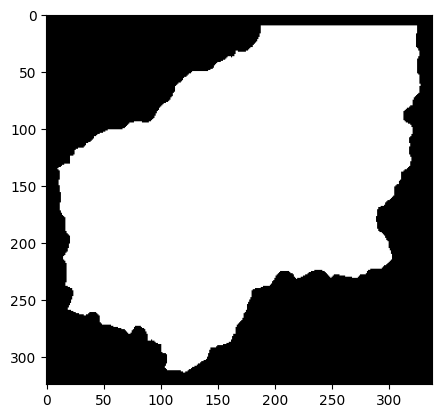

Top :    TORN (variance: 17.31px)
Bottom : TORN (variance: 31.96px)
Left :   TORN (avg: 16.32px)
Right :  TORN (avg: 29.07px)
TOP Distances[5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 31, 54, 54, 62, 63, 95, 97, 98, 99, 100]
BOTTOM Distances[27, 26, 26, 26, 26, 26, 26, 26, 25, 25, 24, 24, 23, 22, 22, 21, 21, 20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 22, 23, 23, 23, 23, 24, 24, 25, 25, 25, 25, 25, 24, 22, 21, 21, 21, 20, 20, 19, 19, 18, 17, 16, 16, 16, 17, 18, 18, 18, 16, 15, 15, 15, 16, 16, 16, 15, 15, 14, 10, 9, 8, 7, 5, 5, 5, 5

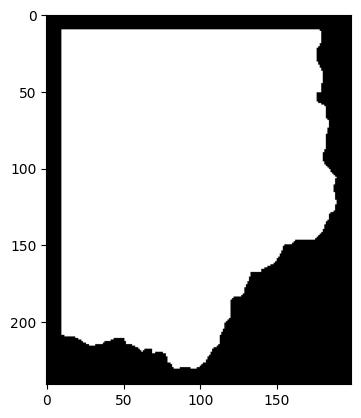

Top :    TORN (variance: 1.85px)
Bottom : TORN (variance: 32.68px)
Left :   TORN (avg: 3.90px)
Right :  TORN (avg: 55.17px)
TOP Distances[20, 18, 17, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5]
BOTTOM Distances[82, 80, 80, 79, 79, 40, 38, 37, 5, 6, 5, 5, 5, 5, 5, 6, 7, 7, 7, 8, 8, 13, 14, 15, 16, 18, 19, 20, 21, 21, 21, 21, 21, 23, 24, 25, 26, 26, 26, 27, 27, 28, 30, 31, 32, 33, 33, 34, 34, 35, 35, 36, 36, 36, 37, 37, 38, 38, 38, 38, 37, 37, 37, 37, 37, 37, 38, 38, 38, 38, 39, 40, 41,

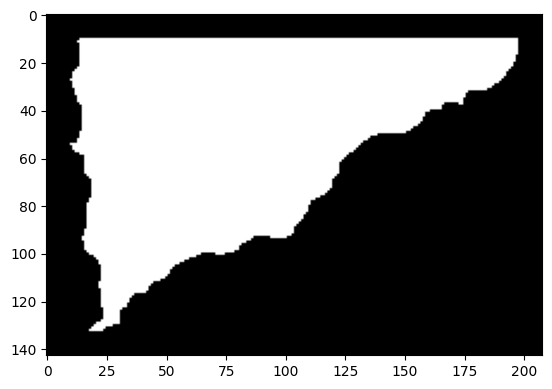

In [7]:
t, b, l, r = [], [], [], []

for current_piece in con: 
    padded_image = cv2.copyMakeBorder(current_piece, 10, 10, 10, 10, borderType=cv2.BORDER_CONSTANT, value=[0,0,0])
    
    gray = cv2.cvtColor(padded_image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    
    points = cv2.findNonZero(thresh)
    
    x_box, y_box, w_box, h_box = cv2.boundingRect(points)

    tol = 1.5 
    top_deviations, bottom_deviations = [], []

    for col in range(x_box, x_box + w_box):
        white_pixels = np.where(thresh[:, col] == 255)[0]
        if len(white_pixels) > 0:
            top_deviations.append(int(white_pixels[0] - y_box))
            bottom_deviations.append(int((y_box + h_box) - white_pixels[-1]))

    std_top = np.std(top_deviations) if top_deviations else 0
    std_bottom = np.std(bottom_deviations) if bottom_deviations else 0
    
    top_is_torn = std_top > tol
    bottom_is_torn = std_bottom > tol
    
    print(f"Top :    {'TORN' if top_is_torn else 'STRAIGHT'} (variance: {std_top:.2f}px)")
    print(f"Bottom : {'TORN' if bottom_is_torn else 'STRAIGHT'} (variance: {std_bottom:.2f}px)")

    left_avg, right_avg = [], []
    for row in range(y_box, y_box + h_box):
        white_pixels = np.where(thresh[row, :] == 255)[0]
        if len(white_pixels) > 0:
            left_avg.append(int(white_pixels[0] - x_box))
            right_avg.append(int((x_box + w_box) - white_pixels[-1]))

    std_left = np.std(left_avg) if left_avg else 0
    std_right = np.std(right_avg) if right_avg else 0
    
    left_is_torn = std_left > tol
    right_is_torn = std_right > tol
    
    print(f"Left :   {'TORN' if left_is_torn else 'STRAIGHT'} (avg: {std_left:.2f}px)")
    print(f"Right :  {'TORN' if right_is_torn else 'STRAIGHT'} (avg: {std_right:.2f}px)")

    a1 = cv2.Canny(thresh, 150, 150)
    y_arr, x_arr = np.where(a1 == 255)
    
    y_pixels, x_pixels = np.where(thresh == 255)
    min_y, max_y = np.min(y_pixels), np.max(y_pixels)
    min_x, max_x = np.min(x_pixels), np.max(x_pixels)
    
    g1 = 5  
    any_torn = False

    if top_is_torn:
        any_torn = True
        b11_top = []
        for col_x in range(min_x, max_x + 1):
            pixels_in_col = y_arr[x_arr == col_x]
            if len(pixels_in_col) > 0:
                b11_top.append((int(col_x), int(np.min(pixels_in_col))))
        
        top_ref_y = int(min_y - g1)
        distances_top = [abs(int(y11) - top_ref_y) for _, y11 in b11_top]
        t.append(distances_top)
        print(f"TOP Distances{distances_top}")
    else:
        t.append([])    

    if bottom_is_torn:
        any_torn = True
        b11_bottom = []
        for col_x in range(min_x, max_x + 1):
            pixels_in_col = y_arr[x_arr == col_x]
            if len(pixels_in_col) > 0:
                b11_bottom.append((int(col_x), int(np.max(pixels_in_col))))
        
        bottom_ref_y = int(max_y + g1)
        distances_bottom = [abs(int(y11) - bottom_ref_y) for _, y11 in b11_bottom]
        b.append(distances_bottom)
        print(f"BOTTOM Distances{distances_bottom}")
    else:
         b.append([])    

    if left_is_torn:
        any_torn = True
        b11_left = []
        for row_y in range(min_y, max_y + 1):
            pixels_in_row = x_arr[y_arr == row_y]
            if len(pixels_in_row) > 0:
                b11_left.append((int(row_y), int(np.min(pixels_in_row))))
        
        left_ref_x = int(min_x - g1)
        distances_left = [abs(int(x11) - left_ref_x) for _, x11 in b11_left]
        l.append(distances_left)
        print(f"LEFT Distances {distances_left}")
    else:
          l.append([])    

    if right_is_torn:
        any_torn = True
        b11_right = []
        for row_y in range(min_y, max_y + 1):
            pixels_in_row = x_arr[y_arr == row_y]
            if len(pixels_in_row) > 0:
                b11_right.append((int(row_y), int(np.max(pixels_in_row))))
        
        right_ref_x = int(max_x + g1)
        distances_right = [abs(int(x11) - right_ref_x) for _, x11 in b11_right]
        r.append(distances_right)
        print(f"RIGHT Distances{distances_right}")
    else:
         r.append([])
    
    plt.imshow(thresh, cmap='gray')
    plt.show()

In [8]:
th = 0.82
tr = 12

def check_match(side1, side2):
    if not isinstance(side1, list) or not isinstance(side2, list):
        return False, 0.0
    if len(side1) == 0 or len(side2) == 0:
        return False, 0.0

    edge1 = np.array(side1 if len(side1) > 2*tr else side1, dtype=float)
    edge2 = np.array(side2 if len(side2) > 2*tr else side2, dtype=float)

    x1 = np.arange(len(edge1))
    slope1, intercept1 = np.polyfit(x1, edge1, 1)
    detrended1 = edge1 - (slope1 * x1 + intercept1)
    roughness1 = np.std(detrended1)

    x2 = np.arange(len(edge2))
    slope2, intercept2 = np.polyfit(x2, edge2, 1)
    detrended2 = edge2 - (slope2 * x2 + intercept2)
    roughness2 = np.std(detrended2)

    if roughness1 < 1.2 or roughness2 < 1.2:
        return False, 0.0
      
    norm1 = (edge1 - np.min(edge1)) / (np.max(edge1) - np.min(edge1) + 1e-6)
    norm2 = (edge2 - np.min(edge2)) / (np.max(edge2) - np.min(edge2) + 1e-6)

    if len(norm1) < len(norm2):
        shorter, longer = norm1, norm2
    else:
        shorter, longer = norm2, norm1
        
    s_len, l_len = len(shorter), len(longer)
    best_score = 0.0

    for direction in ["Forward", "Reversed"]:
        test_shorter = shorter if direction == "Forward" else shorter[::-1]
        
        for offset in range(l_len - s_len + 1):
            segment = longer[offset:offset + s_len]
            
            dist_direct = np.mean(np.abs(test_shorter - segment))
            score_direct = 1.0 - dist_direct
            
            dist_comp = np.mean(np.abs(test_shorter - (1.0 - segment)))
            score_comp = 1.0 - dist_comp
            
            if score_direct > best_score:
                best_score = score_direct
                
            if score_comp > best_score:
                best_score = score_comp

    confidence = best_score * 100
    if best_score >= th:
        return True, confidence
    else:
        return False, confidence

In [9]:
num_pieces = len(con)

for i in range(num_pieces):
    for j in range(num_pieces):
        if i == j:
            continue
            
        matched, conf = check_match(t[i], b[j])
        status = "MATCHED" if matched else "NOT MATCHED"
        print(f"Piece {i} (TOP) Piece {j} (BOTTOM)  {status} (Confidence {conf:.2f}%)")

        matched, conf = check_match(b[i], t[j])
        status = "MATCHED" if matched else "NOT MATCHED"
        print(f"Piece {i} (BOTTOM) Piece {j} (TOP)  {status} (Confidence {conf:.2f}%)")

for i in range(num_pieces):
    for j in range(num_pieces):
        if i == j:
            continue

        matched, conf = check_match(l[i], r[j])
        status = "MATCHED" if matched else "NOT MATCHED"
        print(f"Piece {i} (LEFT)  Piece {j} (RIGHT)  {status} (Confidence {conf:.2f}%)")

        matched, conf = check_match(r[i], l[j])
        status = "MATCHED" if matched else "NOT MATCHED"
        print(f"Piece {i} (RIGHT)  Piece {j} (LEFT)  {status} (Confidence {conf:.2f}%)")

Piece 0 (TOP) Piece 1 (BOTTOM)  MATCHED (Confidence 84.58%)
Piece 0 (BOTTOM) Piece 1 (TOP)  NOT MATCHED (Confidence 0.00%)
Piece 0 (TOP) Piece 2 (BOTTOM)  MATCHED (Confidence 83.78%)
Piece 0 (BOTTOM) Piece 2 (TOP)  NOT MATCHED (Confidence 0.00%)
Piece 0 (TOP) Piece 3 (BOTTOM)  NOT MATCHED (Confidence 0.00%)
Piece 0 (BOTTOM) Piece 3 (TOP)  NOT MATCHED (Confidence 0.00%)
Piece 0 (TOP) Piece 4 (BOTTOM)  NOT MATCHED (Confidence 75.64%)
Piece 0 (BOTTOM) Piece 4 (TOP)  NOT MATCHED (Confidence 0.00%)
Piece 0 (TOP) Piece 5 (BOTTOM)  MATCHED (Confidence 87.45%)
Piece 0 (BOTTOM) Piece 5 (TOP)  NOT MATCHED (Confidence 0.00%)
Piece 0 (TOP) Piece 6 (BOTTOM)  MATCHED (Confidence 90.05%)
Piece 0 (BOTTOM) Piece 6 (TOP)  NOT MATCHED (Confidence 0.00%)
Piece 0 (TOP) Piece 7 (BOTTOM)  NOT MATCHED (Confidence 81.30%)
Piece 0 (BOTTOM) Piece 7 (TOP)  NOT MATCHED (Confidence 0.00%)
Piece 0 (TOP) Piece 8 (BOTTOM)  NOT MATCHED (Confidence 72.02%)
Piece 0 (BOTTOM) Piece 8 (TOP)  NOT MATCHED (Confidence 0.00%)
P

In [10]:
# plt.imshow(con[19])
# plt.show()

In [11]:
def get_thresh(img):
    _, thresh = cv2.threshold(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 15, 255, cv2.THRESH_BINARY)
    return thresh

def merge_canvases(imgA, imgB, threshA, threshB, dx, dy):
    hA, wA = imgA.shape[:2]
    hB, wB = imgB.shape[:2]
    min_x, max_x = min(0, dx), max(wA, wB + dx)
    min_y, max_y = min(0, dy), max(hA, hB + dy)
    
    canvas = np.zeros((max_y - min_y, max_x - min_x, 3), dtype=np.uint8)
    canvas[-min_y:-min_y+hA, -min_x:-min_x+wA][threshA > 0] = imgA[threshA > 0]
    canvas[dy-min_y:dy-min_y+hB, dx-min_x:dx-min_x+wB][threshB > 0] = imgB[threshB > 0]
    return canvas

def stitch_by_edge(img2, img3, ref="bottom"):
    thresh2, thresh3 = get_thresh(img2), get_thresh(img3)
    p2, p3 = np.where(thresh2 == 255), np.where(thresh3 == 255)
    dy = (int(p2[0].max()) - int(p3[0].max())) if ref == "bottom" else (int(p2[0].min()) - int(p3[0].min()))
    
    y2, x2 = np.where(cv2.Canny(thresh2, 150, 150) == 255)
    b2 = {r: np.max(x2[y2 == r]) for r in range(np.min(p2[0]), np.max(p2[0]) + 1) if len(x2[y2 == r]) > 0}
    
    y3, x3 = np.where(cv2.Canny(thresh3, 150, 150) == 255)
    b3 = {r: np.min(x3[y3 == r]) for r in range(np.min(p3[0]), np.max(p3[0]) + 1) if len(x3[y3 == r]) > 0}
    
    dx = int(np.percentile([b2[y + dy] - x for y, x in b3.items() if (y + dy) in b2], 90))
    return merge_canvases(img2, img3, thresh2, thresh3, dx, dy)

def stitch_by_margin(img0, img1, side="left"):
    thresh0, thresh1 = get_thresh(img0), get_thresh(img1)
    y0, x0 = np.where(thresh0 == 255)
    y1, x1 = np.where(thresh1 == 255)
    
    dx = (np.min(x0) if side == "left" else np.max(x0)) - (np.min(x1) if side == "left" else np.max(x1))
    bottom0 = {c: np.max(y0[x0 == c]) for c in np.unique(x0)}
    top1 = {c + dx: np.min(y1[x1 == c]) for c in np.unique(x1)}
    
    dy = int(np.percentile([bottom0[c] - top1[c] + 1 for c in bottom0 if c in top1], 92))
    return merge_canvases(img0, img1, thresh0, thresh1, dx, dy)

def ad_stitch(img_base, img_patch):
    m_b = (cv2.cvtColor(img_base, cv2.COLOR_BGR2GRAY) > 15).astype(np.uint8) * 255
    m_p = (cv2.cvtColor(img_patch, cv2.COLOR_BGR2GRAY) > 15).astype(np.uint8) * 255
    
    y_p, x_p = np.where(cv2.Canny(m_p, 50, 150) == 255)
    dist_out = cv2.distanceTransform(~m_b, cv2.DIST_L2, 5)
    dist_in = cv2.distanceTransform(m_b, cv2.DIST_L2, 5)
    
    h_b, w_b = img_base.shape[:2]
    h_p, w_p = img_patch.shape[:2]
    best_dx, best_dy, min_score = 0, 0, float('inf')
    
    for dy in range(-int(h_b * 0.4), int(h_b * 0.8)):
        for dx in range(int(w_b * 0.1), int(w_b * 1.2)):
            sy, sx = y_p + dy, x_p + dx
            valid = (sy >= 0) & (sy < h_b) & (sx >= 0) & (sx < w_b)
            if np.sum(valid) < 15:
                continue
                
            vy, vx = sy[valid], sx[valid]
            ol = m_b[vy, vx] == 255
            ol_cnt = np.sum(ol)
            if ol_cnt / len(vy) > 0.35:
                continue
                
            n_vy, n_vx = vy[~ol], vx[~ol]
            if len(n_vy) == 0:
                continue
                
            gaps = dist_out[n_vy, n_vx]
            penalty = np.mean(dist_in[vy[ol], vx[ol]]) * 3.0 if ol_cnt > 0 else 0.0
            score = np.mean(gaps) + penalty - np.sum(gaps < 4.0) * 0.2
            
            if score < min_score:
                min_score, best_dx, best_dy = score, dx, dy

    oy, ox = max(0, -best_dy), max(0, -best_dx)
    mh, mw = max(h_b + oy, h_p + best_dy + oy), max(w_b + ox, w_p + best_dx + ox)
    
    canvas = np.zeros((mh, mw, 3), dtype=np.uint8)
    canvas[oy:oy+h_b, ox:ox+w_b] = img_base
    
    py, px = best_dy + oy, best_dx + ox
    canvas[py:py+h_p, px:px+w_p][m_p == 255] = img_patch[m_p == 255]
    return canvas

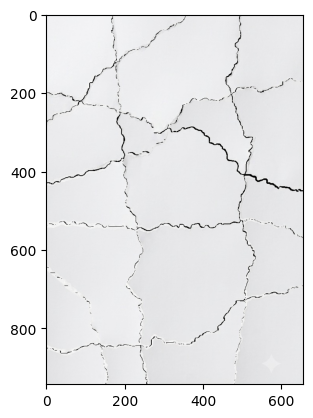

In [12]:
L = con
canvas = L[0]
canvas = stitch_by_edge(canvas, L[1], ref="bottom")
canvas = stitch_by_edge(canvas, L[2], ref="bottom")
canvas = stitch_by_margin(L[4], canvas, side="left")

canvas75 = stitch_by_edge(L[7], L[5], ref="bottom")
canvas = stitch_by_margin(canvas75, canvas, side="left")

canvas63 = stitch_by_margin(L[6], L[3], side="right")
canvas638 = stitch_by_margin(L[8], canvas63, side="right")
canvas = stitch_by_edge(canvas, canvas638, ref="bottom")

canvas9_10 = stitch_by_edge(L[9], L[10], ref="bottom")
canvas = stitch_by_margin(canvas9_10, canvas, side="left")

canvas_12_11 = ad_stitch(L[12], L[11])
canvas = stitch_by_margin(canvas_12_11, canvas, side="left")
canvas = stitch_by_margin(L[15], canvas, side="left")

canvas_19_16 = ad_stitch(L[19], L[16])
canvas_13_14 = ad_stitch(L[13], L[14])

c1 = stitch_by_margin(L[17], canvas_13_14, side="right")
c2 = stitch_by_edge(canvas_19_16, L[20], ref="top")
c2 = stitch_by_edge(c2, L[18], ref="top")
c2 = stitch_by_edge(c2, c1, ref="top")

canvas = stitch_by_margin(c2, canvas, side="left")

plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.show()

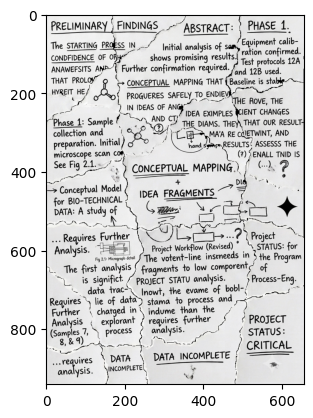

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


image_path = r"Z:\Internship\Tasks\Edge Detection\image\test4.png"
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"Could not load image at {image_path}")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (3, 3), 0)

_, thresh = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

min_area = 500
valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]

pieces = []
masks = []
boundaries = []

for contour in valid_contours:
    x, y, w, h = cv2.boundingRect(contour)
    cropped_piece = image[y:y+h, x:x+w]
    
    mask = np.zeros_like(closed)
    cv2.drawContours(mask, [contour], -1, 255, -1)
    cropped_mask = mask[y:y+h, x:x+w]
    
    dilated = cv2.dilate(cropped_mask, np.ones((3,3), np.uint8), iterations=1)
    boundary = cv2.absdiff(dilated, cropped_mask)
    
    isolated_piece = cv2.bitwise_and(cropped_piece, cropped_piece, mask=cropped_mask)
    
    pieces.append(isolated_piece)
    masks.append(cropped_mask)
    boundaries.append(boundary)

num_pieces = len(pieces)

def find_best_translation(i, j):
  
    bi, bj = boundaries[i], boundaries[j]
    mi, mj = masks[i], masks[j]
    hi, wi = bi.shape
    hj, wj = bj.shape
    
    padded_b = cv2.copyMakeBorder(bi, hj, hj, wj, wj, cv2.BORDER_CONSTANT, value=0)
    padded_m = cv2.copyMakeBorder(mi, hj, hj, wj, wj, cv2.BORDER_CONSTANT, value=0)
    
    corr = cv2.matchTemplate(padded_b, bj, cv2.TM_CCORR)
    
    flat_indices = np.argsort(corr.ravel())[-150:][::-1]
    best_score = -1
    best_dx, best_dy = 0, 0
    
    for idx in flat_indices:
        r, c = np.unravel_index(idx, corr.shape)
        
        dy = r - hj
        dx = c - wj
        
        y_start_i, y_end_i = max(0, dy), min(hi, dy + hj)
        x_start_i, x_end_i = max(0, dx), min(wi, dx + wj)
        y_start_j, y_end_j = max(0, -dy), min(hj, hi - dy)
        x_start_j, x_end_j = max(0, -dx), min(wj, wi - dx)
        
        if (y_end_i <= y_start_i) or (x_end_i <= x_start_i):
            continue
            
        overlap_mask_i = mi[y_start_i:y_end_i, x_start_i:x_end_i]
        overlap_mask_j = mj[y_start_j:y_end_j, x_start_j:x_end_j]
        
        overlap_area = np.sum((overlap_mask_i > 0) & (overlap_mask_j > 0))
        min_mask_area = min(np.sum(mi > 0), np.sum(mj > 0))
        
        if overlap_area > (0.015 * min_mask_area): 
            continue
            
        overlap_bound_i = bi[y_start_i:y_end_i, x_start_i:x_end_i]
        overlap_bound_j = bj[y_start_j:y_end_j, x_start_j:x_end_j]
        contact_score = np.sum((overlap_bound_i > 0) & (overlap_bound_j > 0))
        
        if contact_score > best_score:
            best_score = contact_score
            best_dx = dx
            best_dy = dy
            
    return best_dx, best_dy, best_score

match_graph = []
for i in range(num_pieces):
    for j in range(i + 1, num_pieces):
        dx, dy, score = find_best_translation(i, j)
        if score > 5: 
            match_graph.append({'i': i, 'j': j, 'dx': dx, 'dy': dy, 'score': score})

match_graph.sort(key=lambda x: x['score'], reverse=True)


areas = [np.sum(m > 0) for m in masks]
root_piece = np.argmax(areas)

positions = {root_piece: (0, 0)}
placed = {root_piece}

while len(placed) < num_pieces:
    progress = False
    for match in match_graph:
        i, j = match['i'], match['j']
        dx, dy = match['dx'], match['dy']
        
        if (i in placed) and (j not in placed):
            ref_x, ref_y = positions[i]
            positions[j] = (ref_x + dx, ref_y + dy)
            placed.add(j)
            progress = True
            break
        elif (j in placed) and (i not in placed):
            ref_x, ref_y = positions[j]
            positions[i] = (ref_x - dx, ref_y - dy)
            placed.add(i)
            progress = True
            break
            
    if not progress:
        unplaced = set(range(num_pieces)) - placed
        if not unplaced:
            break
        fallback_target = list(unplaced)[0]
        positions[fallback_target] = (0, 0)
        placed.add(fallback_target)


xs = [pos[0] for pos in positions.values()]
ys = [pos[1] for pos in positions.values()]
min_x, min_y = min(xs), min(ys)

normalized_positions = {k: (pos[0] - min_x, pos[1] - min_y) for k, pos in positions.items()}

max_w = 0
max_h = 0
for idx, (px, py) in normalized_positions.items():
    h, w = pieces[idx].shape[:2]
    max_w = max(max_w, px + w)
    max_h = max(max_h, py + h)

canvas = np.zeros((max_h, max_w, 3), dtype=np.uint8)

for idx, (px, py) in normalized_positions.items():
    img = pieces[idx]
    mask = masks[idx]
    h, w = img.shape[:2]
    
    roi = canvas[py:py+h, px:px+w]
    roi[mask > 0] = img[mask > 0]

plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))

plt.show()

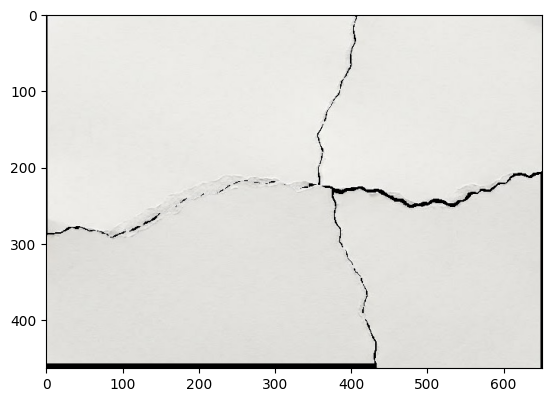

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


image_path = r"Z:\Internship\Tasks\Edge Detection\image\img1.png"
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"Could not load image at {image_path}")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (3, 3), 0)

_, thresh = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

min_area = 500
valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]

pieces = []
masks = []
boundaries = []

for contour in valid_contours:
    x, y, w, h = cv2.boundingRect(contour)
    cropped_piece = image[y:y+h, x:x+w]
    
    mask = np.zeros_like(closed)
    cv2.drawContours(mask, [contour], -1, 255, -1)
    cropped_mask = mask[y:y+h, x:x+w]
    
    dilated = cv2.dilate(cropped_mask, np.ones((3,3), np.uint8), iterations=1)
    boundary = cv2.absdiff(dilated, cropped_mask)
    
    isolated_piece = cv2.bitwise_and(cropped_piece, cropped_piece, mask=cropped_mask)
    
    pieces.append(isolated_piece)
    masks.append(cropped_mask)
    boundaries.append(boundary)

num_pieces = len(pieces)

def find_best_translation(i, j):
    """
    Finds the exact (dx, dy) translation to place piece j relative to piece i.
    Uses 2D cross-correlation of boundaries, avoiding internal mask overlap.
    """
    bi, bj = boundaries[i], boundaries[j]
    mi, mj = masks[i], masks[j]
    hi, wi = bi.shape
    hj, wj = bj.shape
    
    padded_b = cv2.copyMakeBorder(bi, hj, hj, wj, wj, cv2.BORDER_CONSTANT, value=0)
    padded_m = cv2.copyMakeBorder(mi, hj, hj, wj, wj, cv2.BORDER_CONSTANT, value=0)
    
    corr = cv2.matchTemplate(padded_b, bj, cv2.TM_CCORR)
    
    flat_indices = np.argsort(corr.ravel())[-150:][::-1]
    best_score = -1
    best_dx, best_dy = 0, 0
    
    for idx in flat_indices:
        r, c = np.unravel_index(idx, corr.shape)
        
        dy = r - hj
        dx = c - wj
        
        y_start_i, y_end_i = max(0, dy), min(hi, dy + hj)
        x_start_i, x_end_i = max(0, dx), min(wi, dx + wj)
        y_start_j, y_end_j = max(0, -dy), min(hj, hi - dy)
        x_start_j, x_end_j = max(0, -dx), min(wj, wi - dx)
        
        if (y_end_i <= y_start_i) or (x_end_i <= x_start_i):
            continue
            
        overlap_mask_i = mi[y_start_i:y_end_i, x_start_i:x_end_i]
        overlap_mask_j = mj[y_start_j:y_end_j, x_start_j:x_end_j]
        
        overlap_area = np.sum((overlap_mask_i > 0) & (overlap_mask_j > 0))
        min_mask_area = min(np.sum(mi > 0), np.sum(mj > 0))
        
        if overlap_area > (0.015 * min_mask_area): 
            continue
            
        overlap_bound_i = bi[y_start_i:y_end_i, x_start_i:x_end_i]
        overlap_bound_j = bj[y_start_j:y_end_j, x_start_j:x_end_j]
        contact_score = np.sum((overlap_bound_i > 0) & (overlap_bound_j > 0))
        
        if contact_score > best_score:
            best_score = contact_score
            best_dx = dx
            best_dy = dy
            
    return best_dx, best_dy, best_score

match_graph = []
for i in range(num_pieces):
    for j in range(i + 1, num_pieces):
        dx, dy, score = find_best_translation(i, j)
        if score > 5: 
            match_graph.append({'i': i, 'j': j, 'dx': dx, 'dy': dy, 'score': score})

match_graph.sort(key=lambda x: x['score'], reverse=True)


areas = [np.sum(m > 0) for m in masks]
root_piece = np.argmax(areas)

positions = {root_piece: (0, 0)}
placed = {root_piece}

while len(placed) < num_pieces:
    progress = False
    for match in match_graph:
        i, j = match['i'], match['j']
        dx, dy = match['dx'], match['dy']
        
        if (i in placed) and (j not in placed):
            ref_x, ref_y = positions[i]
            positions[j] = (ref_x + dx, ref_y + dy)
            placed.add(j)
            progress = True
            break
        elif (j in placed) and (i not in placed):
            ref_x, ref_y = positions[j]
            positions[i] = (ref_x - dx, ref_y - dy)
            placed.add(i)
            progress = True
            break
            
    if not progress:
        unplaced = set(range(num_pieces)) - placed
        if not unplaced:
            break
        fallback_target = list(unplaced)[0]
        positions[fallback_target] = (0, 0)
        placed.add(fallback_target)


xs = [pos[0] for pos in positions.values()]
ys = [pos[1] for pos in positions.values()]
min_x, min_y = min(xs), min(ys)

normalized_positions = {k: (pos[0] - min_x, pos[1] - min_y) for k, pos in positions.items()}

max_w = 0
max_h = 0
for idx, (px, py) in normalized_positions.items():
    h, w = pieces[idx].shape[:2]
    max_w = max(max_w, px + w)
    max_h = max(max_h, py + h)

canvas = np.zeros((max_h, max_w, 3), dtype=np.uint8)

for idx, (px, py) in normalized_positions.items():
    img = pieces[idx]
    mask = masks[idx]
    h, w = img.shape[:2]
    
    roi = canvas[py:py+h, px:px+w]
    roi[mask > 0] = img[mask > 0]

plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))

plt.show()

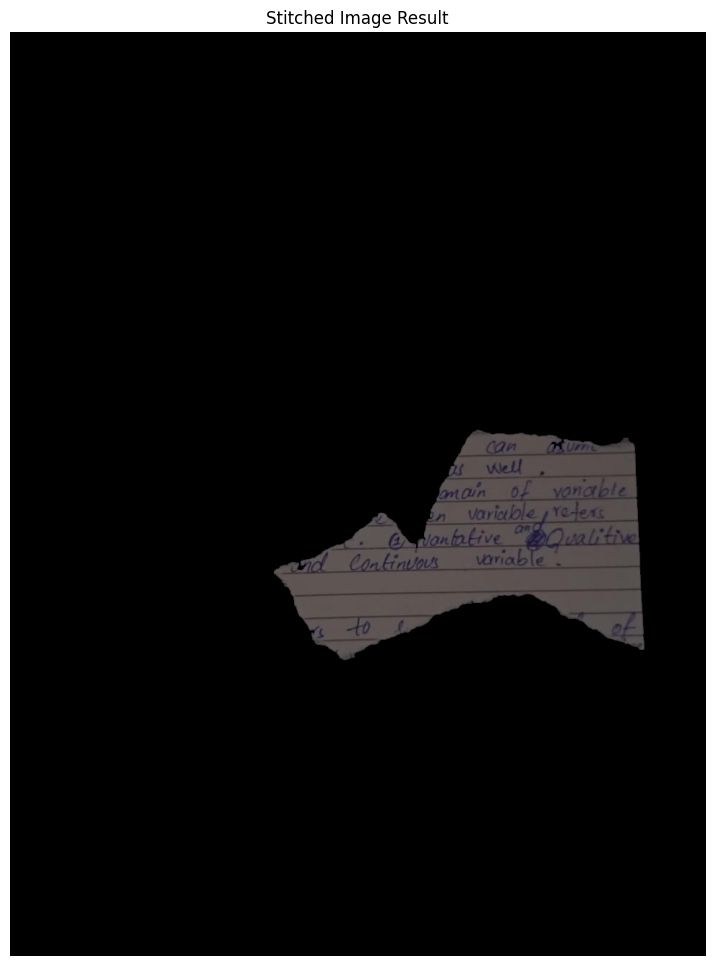

In [15]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def segment_pieces(image_path):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Could not find file at '{image_path}'. Current directory: {os.getcwd()}")
        
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Failed to read image at '{image_path}'.")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Thresholding to separate paper from black gaps
    _, mask = cv2.threshold(gray, 40, 255, cv2.THRESH_BINARY)
    
    # Clean up small noise using morphological operations
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    cleaned_mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)
    
    # Find paper fragment contours
    contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    pieces = []
    min_area = 1000  # Filter out tiny noise contours
    for cnt in contours:
        if cv2.contourArea(cnt) > min_area:
            x, y, w, h = cv2.boundingRect(cnt)
            
            # Extract piece cutout with mask
            piece_mask = np.zeros_like(gray)
            cv2.drawContours(piece_mask, [cnt], -1, 255, -1)
            
            piece_img = cv2.bitwise_and(img, img, mask=piece_mask)
            crop = piece_img[y:y+h, x:x+w]
            crop_mask = piece_mask[y:y+h, x:x+w]
            
            pieces.append({
                'img': crop,
                'mask': crop_mask,
                'orig_pos': (x, y, w, h)
            })
            
    return img, pieces

def align_and_stitch(image_path):
    img, pieces = segment_pieces(image_path)
    
    if len(pieces) <= 1:
        print("Could not isolate multiple distinct pieces.")
        return img

    sift = cv2.SIFT_create()
    canvas_h, canvas_w = img.shape[:2]
    stitched_canvas = np.zeros((canvas_h, canvas_w, 3), dtype=np.uint8)
    
    # Sort pieces by area (largest piece serves as base anchor)
    pieces.sort(key=lambda p: p['orig_pos'][2] * p['orig_pos'][3], reverse=True)
    ref_piece = pieces[0]
    
    # Place base piece on canvas
    rx, ry, rw, rh = ref_piece['orig_pos']
    stitched_canvas[ry:ry+rh, rx:rx+rw] = ref_piece['img']
    
    # Match remaining pieces
    for i in range(1, len(pieces)):
        piece = pieces[i]
        
        kp1, des1 = sift.detectAndCompute(cv2.cvtColor(piece['img'], cv2.COLOR_BGR2GRAY), piece['mask'])
        kp2, des2 = sift.detectAndCompute(cv2.cvtColor(stitched_canvas, cv2.COLOR_BGR2GRAY), None)
        
        if des1 is None or des2 is None or len(kp1) < 4 or len(kp2) < 4:
            continue
            
        index_params = dict(algorithm=1, trees=5)
        search_params = dict(checks=50)
        flann = cv2.FlannBasedMatcher(index_params, search_params)
        matches = flann.knnMatch(des1, des2, k=2)
        
        # Stricter ratio test to prevent bad cross-line matching
        good_matches = []
        for match in matches:
            if len(match) == 2:
                m, n = match
                if m.distance < 0.6 * n.distance:
                    good_matches.append(m)
        
        # Estimate Rigid 2D transformation (Translation + Rotation)
        if len(good_matches) >= 6:
            src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
            dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
            
            # Use Partial Affine instead of Homography to prevent stretching
            M, _ = cv2.estimateAffinePartial2D(src_pts, dst_pts, method=cv2.RANSAC, ransacReprojThreshold=3.0)
            
            if M is not None:
                warped_piece = cv2.warpAffine(piece['img'], M, (canvas_w, canvas_h))
                warped_mask = cv2.warpAffine(piece['mask'], M, (canvas_w, canvas_h))
                
                mask_3ch = cv2.cvtColor(warped_mask, cv2.COLOR_GRAY2BGR) > 0
                stitched_canvas = np.where(mask_3ch, warped_piece, stitched_canvas)

    return stitched_canvas

# Execution & Display
image_file = r"Z:\Internship\Tasks\Edge Detection\image\test7.jpeg"
result_bgr = align_and_stitch(image_file)

# Convert BGR (OpenCV format) to RGB (Matplotlib format)
result_rgb = cv2.cvtColor(result_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 12))
plt.imshow(result_rgb)
plt.title("Stitched Image Result")
plt.axis("off")
plt.show()